# 🎓 IIT NIRF 2025 — Comprehensive Analytics
### Exploratory Analysis · Correlation · PCA · KMeans Clustering



## 0. Setup & Data Loading

In [1]:
# ── Install / imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED',
           '#DB2777', '#0891B2', '#65A30D', '#EA580C', '#6366F1']
GEN_COLORS = {
    'Gen1_Pre1962':    '#1E3A8A',
    'Gen2_1962_2000':  '#2563EB',
    'Gen3_2001_2010':  '#F59E0B',
    'Gen4_2011_plus':  '#DC2626',
}
GEN_LABELS = {
    'Gen1_Pre1962':   'Gen-1 (Pre 1962)',
    'Gen2_1962_2000': 'Gen-2 (1962–2000)',
    'Gen3_2001_2010': 'Gen-3 (2001–2010)',
    'Gen4_2011_plus': 'Gen-4 (2011+)',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load all CSVs ──────────────────────────────────────────────────
# ⚠️  Upload the 11 CSV files to Colab first (Files panel → Upload),
#     OR mount Google Drive and update the BASE_PATH below.

BASE_PATH = ''   # e.g. '/content/drive/MyDrive/IIT_NIRF/' if using Drive

master   = pd.read_csv(BASE_PATH + '00_MASTER_IIT_NIRF_2025.csv')
scores   = pd.read_csv(BASE_PATH + '01_nirf_category_scores.csv')
faculty  = pd.read_csv(BASE_PATH + '02_faculty_and_students.csv')
phd      = pd.read_csv(BASE_PATH + '03_phd_profile.csv')
place    = pd.read_csv(BASE_PATH + '04_placement_outcomes.csv')
patents  = pd.read_csv(BASE_PATH + '05_patents.csv')
funding  = pd.read_csv(BASE_PATH + '06_research_funding.csv')
fin      = pd.read_csv(BASE_PATH + '07_financials.csv')
derived  = pd.read_csv(BASE_PATH + '08_derived_metrics.csv')
age_grp  = pd.read_csv(BASE_PATH + '09_faculty_age_group_summary.csv')
join_per = pd.read_csv(BASE_PATH + '10_faculty_joining_period_summary.csv')

# Convenience: short labels with rank for x-axis
master['label'] = master['short_name'].str.replace('IIT ', '', regex=False)
master_s = master.sort_values('nirf_rank').reset_index(drop=True)

print(f'Master shape: {master.shape}')
master[['short_name','nirf_rank','nirf_score','generation']].head()

Master shape: (22, 38)


,short_name,nirf_rank,nirf_score,generation
0,IIT Madras,1,88.72,Gen1_Pre1962
1,IIT Delhi,2,85.74,Gen1_Pre1962
2,IIT Bombay,3,83.65,Gen1_Pre1962
3,IIT Kanpur,4,81.82,Gen1_Pre1962
4,IIT Kharagpur,5,78.69,Gen1_Pre1962


---
## 1. Exploratory Visualizations

### 1.1  NIRF Score vs Rank

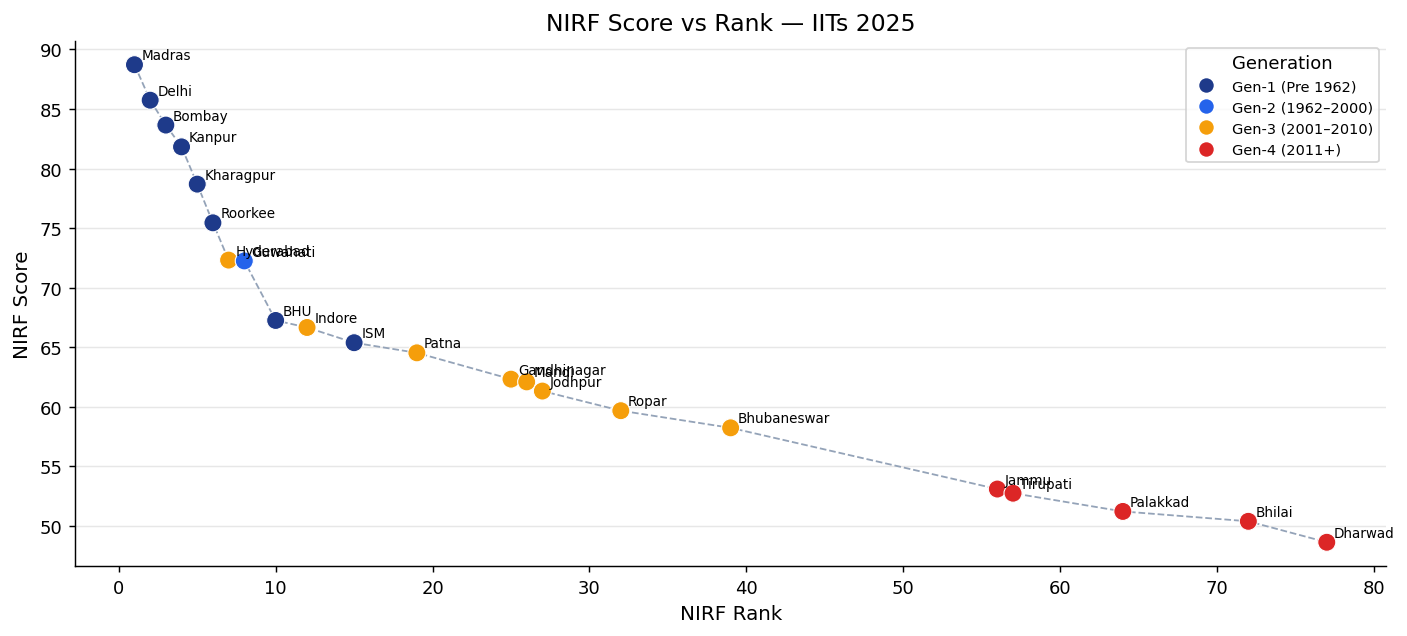

Saved: 01_score_vs_rank.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = [GEN_COLORS[g] for g in master_s['generation']]
ax.scatter(master_s['nirf_rank'], master_s['nirf_score'],
           c=colors, s=100, edgecolors='white', linewidths=0.6, zorder=3)
for _, row in master_s.iterrows():
    ax.annotate(row['label'], (row['nirf_rank'], row['nirf_score']),
                textcoords='offset points', xytext=(4, 3), fontsize=7.5)
ax.plot(master_s['nirf_rank'], master_s['nirf_score'],
        color='#94A3B8', lw=1, linestyle='--', zorder=2)
ax.set(xlabel='NIRF Rank', ylabel='NIRF Score',
       title='NIRF Score vs Rank — IITs 2025')
ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                  markersize=9, label=GEN_LABELS[g])
           for g, c in GEN_COLORS.items()]
ax.legend(handles=handles, title='Generation', fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('01_score_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 01_score_vs_rank.png')

### 1.2  NIRF Sub-scores (TLR, RPC, GO, OI, Perception) vs Rank — Panel Plot

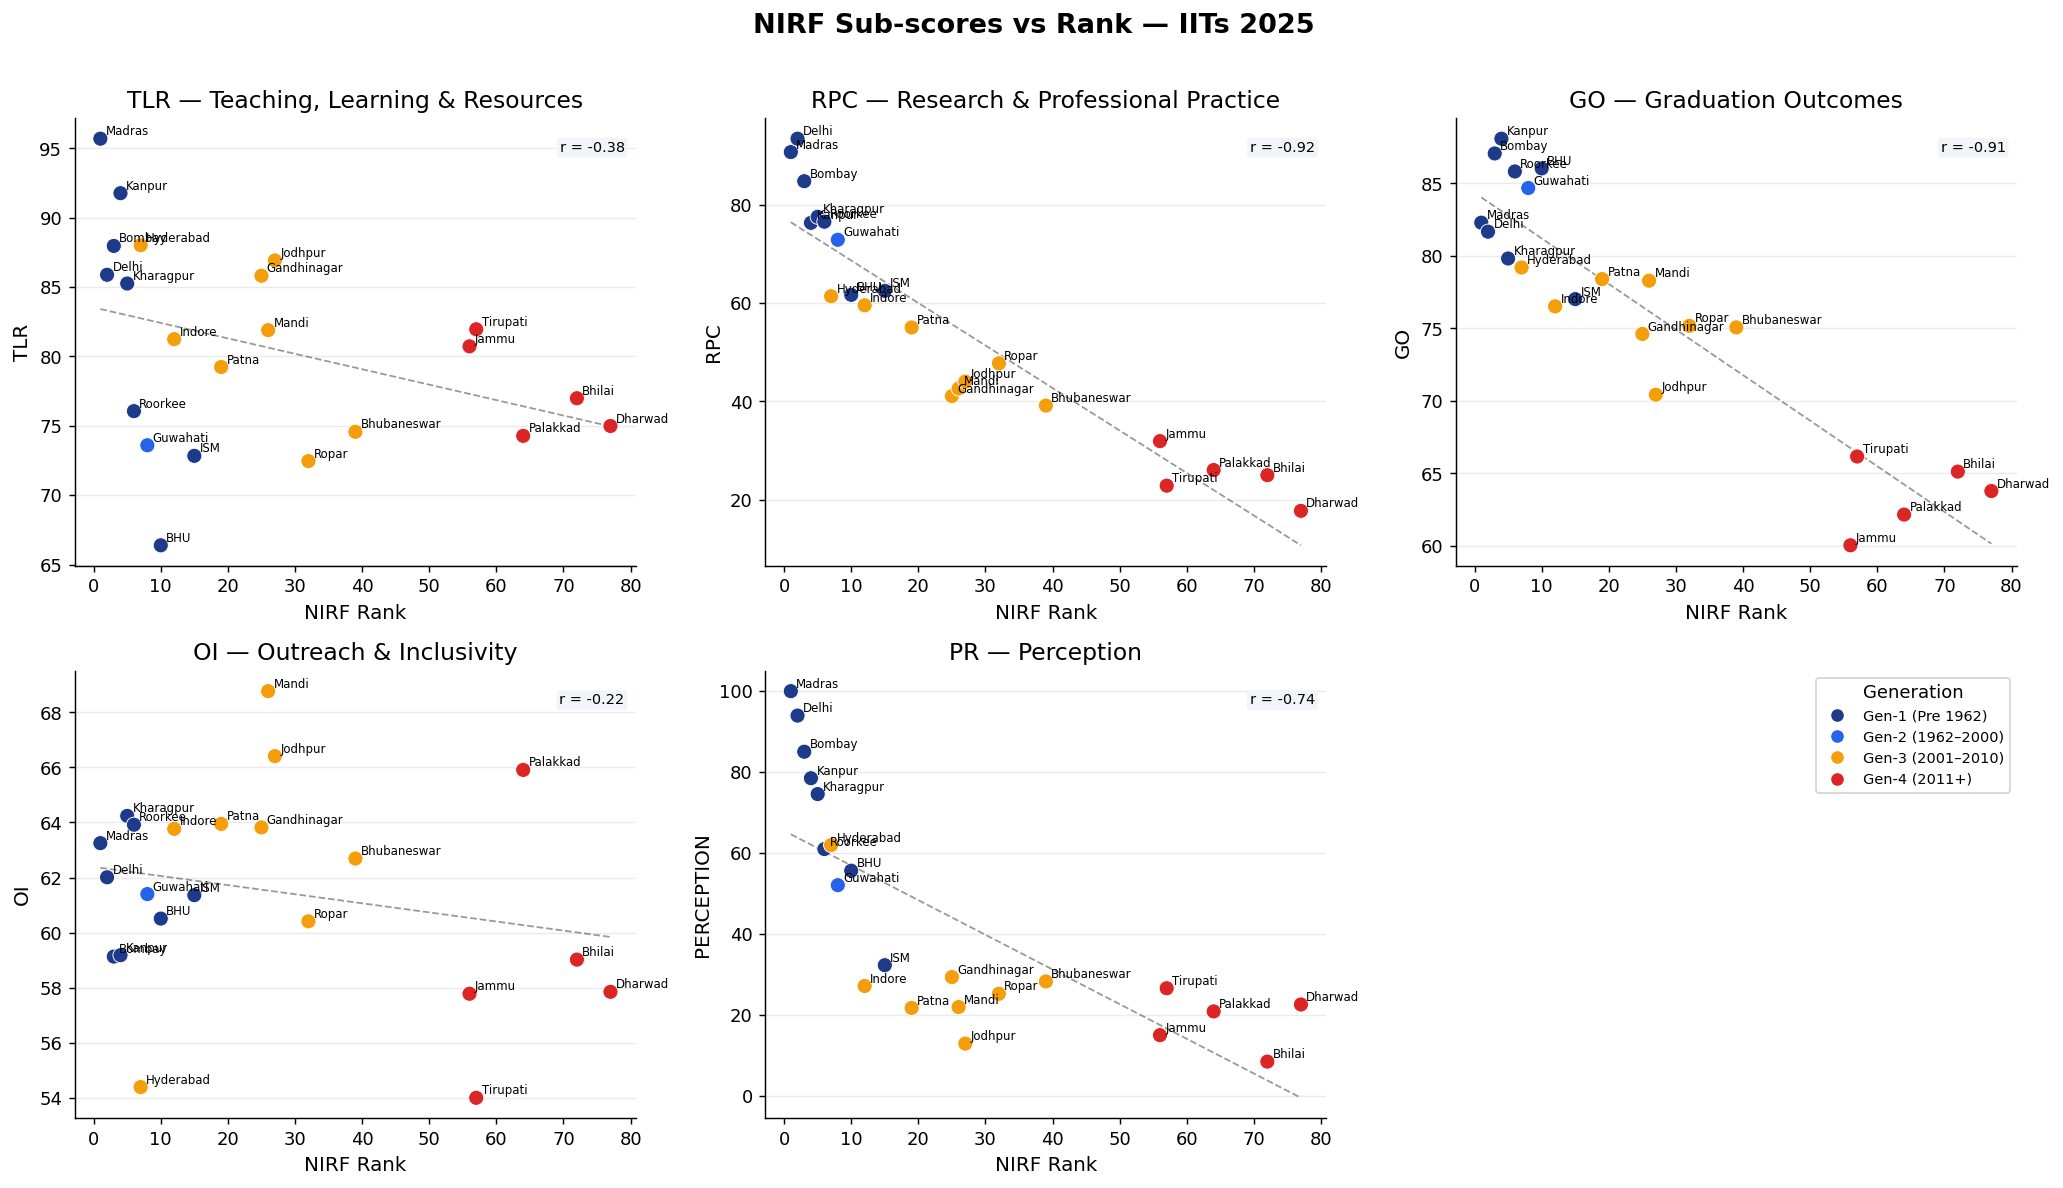

Saved: 02_subscores_vs_rank.png


In [4]:
score_cols = [
    ('tlr_score',         'TLR — Teaching, Learning & Resources'),
    ('rpc_score',         'RPC — Research & Professional Practice'),
    ('go_score',          'GO — Graduation Outcomes'),
    ('oi_score',          'OI — Outreach & Inclusivity'),
    ('perception_score',  'PR — Perception'),
]
df_s = master_s.copy()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, title) in enumerate(score_cols):
    ax = axes[i]
    c = [GEN_COLORS[g] for g in df_s['generation']]
    ax.scatter(df_s['nirf_rank'], df_s[col], c=c, s=70,
               edgecolors='white', lw=0.5, zorder=3)
    for _, row in df_s.iterrows():
        ax.annotate(row['label'], (row['nirf_rank'], row[col]),
                    textcoords='offset points', xytext=(3, 2), fontsize=6.5)
    # trend line
    z = np.polyfit(df_s['nirf_rank'], df_s[col], 1)
    p = np.poly1d(z)
    xx = np.linspace(df_s['nirf_rank'].min(), df_s['nirf_rank'].max(), 100)
    ax.plot(xx, p(xx), 'k--', lw=1, alpha=0.4)
    corr = df_s['nirf_rank'].corr(df_s[col])
    ax.set(xlabel='NIRF Rank', ylabel=col.replace('_score','').upper(),
           title=title)
    ax.text(0.98, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='#F1F5F9', ec='none'))
    ax.grid(axis='y', alpha=0.25)

handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,
                   markersize=8,label=GEN_LABELS[g])
           for g,c in GEN_COLORS.items()]
axes[-1].legend(handles=handles, title='Generation', fontsize=8)
axes[-1].axis('off')
fig.suptitle('NIRF Sub-scores vs Rank — IITs 2025', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_subscores_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 02_subscores_vs_rank.png')

### 1.3  Placement Median Salary vs Rank

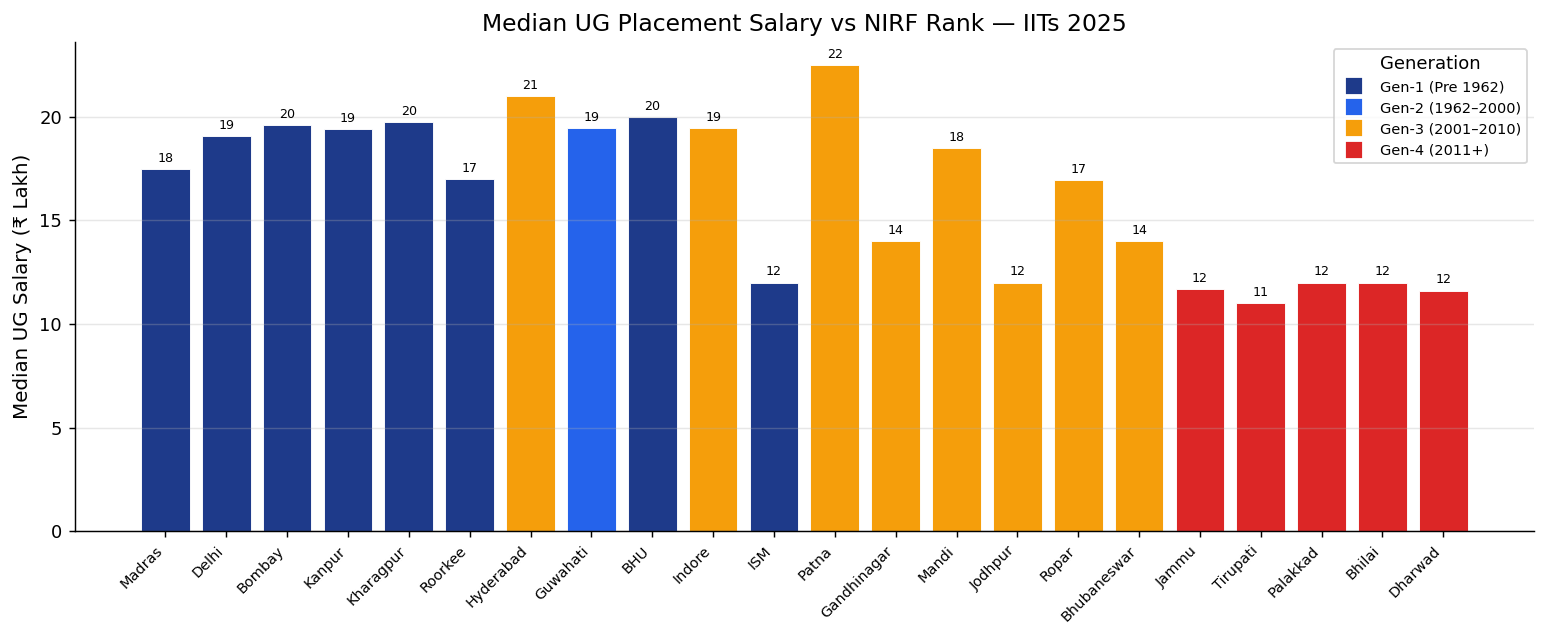

Saved: 03_salary_vs_rank.png


In [5]:
df_p = master_s.dropna(subset=['ug_median_salary_lakh']).copy()

fig, ax = plt.subplots(figsize=(12, 5))
c = [GEN_COLORS[g] for g in df_p['generation']]
bars = ax.bar(range(len(df_p)), df_p['ug_median_salary_lakh'], color=c,
              edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(df_p)))
ax.set_xticklabels(df_p['label'], rotation=45, ha='right', fontsize=8)
ax.set(ylabel='Median UG Salary (₹ Lakh)',
       title='Median UG Placement Salary vs NIRF Rank — IITs 2025')
# value labels
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.0f}',
            ha='center', va='bottom', fontsize=7)
ax.grid(axis='y', alpha=0.3)
handles = [Line2D([0],[0],marker='s',color='w',markerfacecolor=c,
                   markersize=10,label=GEN_LABELS[g])
           for g,c in GEN_COLORS.items()]
ax.legend(handles=handles, title='Generation', fontsize=8)
plt.tight_layout()
plt.savefig('03_salary_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 03_salary_vs_rank.png')

### 1.4  Faculty Strength & PhD Students vs Rank

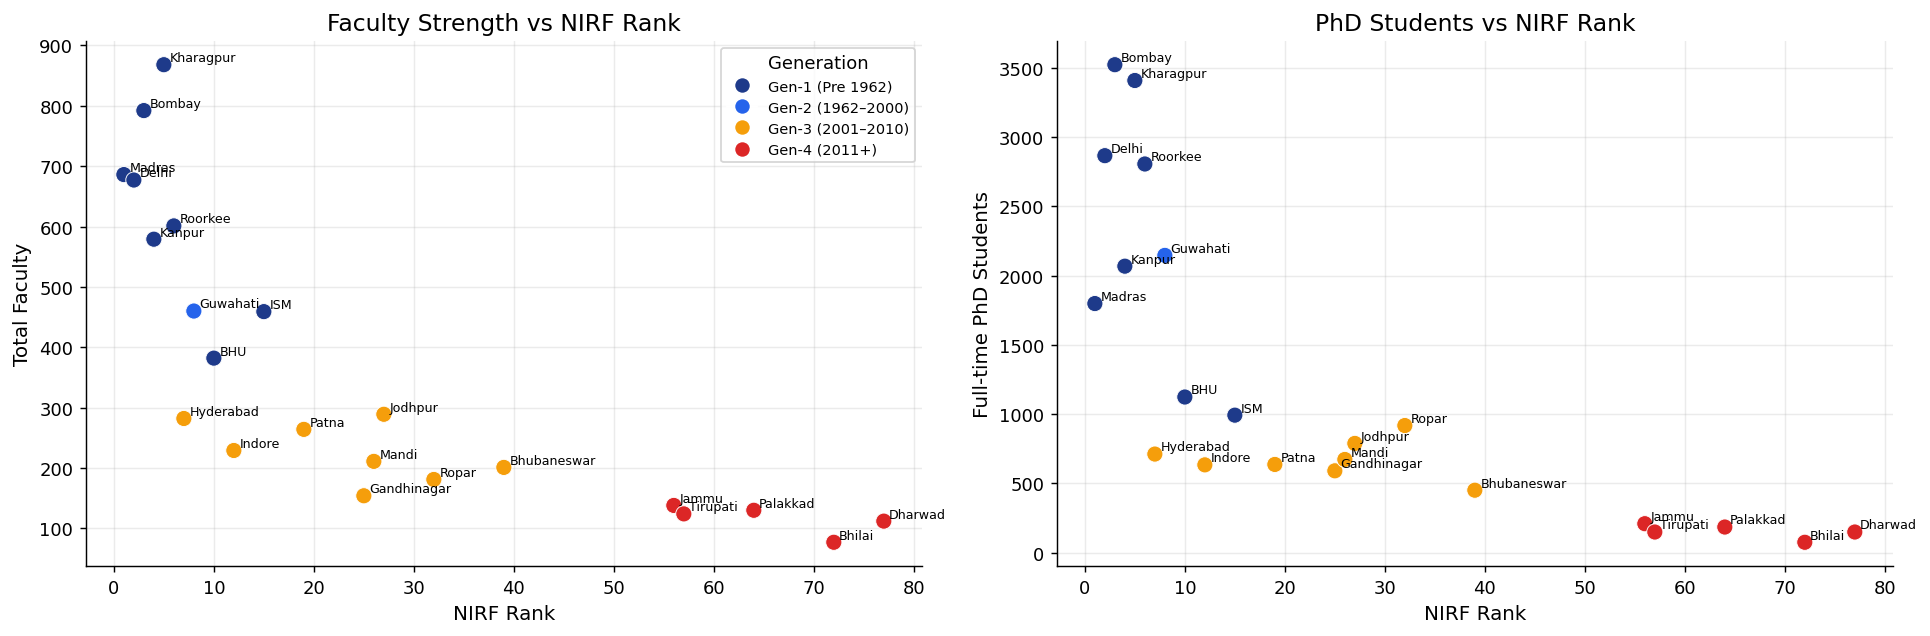

Saved: 04_faculty_phd_vs_rank.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Faculty
c = [GEN_COLORS[g] for g in master_s['generation']]
ax1.scatter(master_s['nirf_rank'], master_s['total_faculty'], c=c, s=80,
            edgecolors='white', lw=0.5, zorder=3)
for _, row in master_s.iterrows():
    ax1.annotate(row['label'], (row['nirf_rank'], row['total_faculty']),
                 textcoords='offset points', xytext=(3, 2), fontsize=7)
ax1.set(xlabel='NIRF Rank', ylabel='Total Faculty',
        title='Faculty Strength vs NIRF Rank')
ax1.grid(alpha=0.25)

# PhD students
ax2.scatter(master_s['nirf_rank'], master_s['phd_students_fulltime'], c=c, s=80,
            edgecolors='white', lw=0.5, zorder=3)
for _, row in master_s.iterrows():
    ax2.annotate(row['label'], (row['nirf_rank'], row['phd_students_fulltime']),
                 textcoords='offset points', xytext=(3, 2), fontsize=7)
ax2.set(xlabel='NIRF Rank', ylabel='Full-time PhD Students',
        title='PhD Students vs NIRF Rank')
ax2.grid(alpha=0.25)

handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,
                   markersize=9,label=GEN_LABELS[g])
           for g,c in GEN_COLORS.items()]
ax1.legend(handles=handles, title='Generation', fontsize=8)
plt.tight_layout()
plt.savefig('04_faculty_phd_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 04_faculty_phd_vs_rank.png')

### 1.5  Research Funding & Patents vs Rank

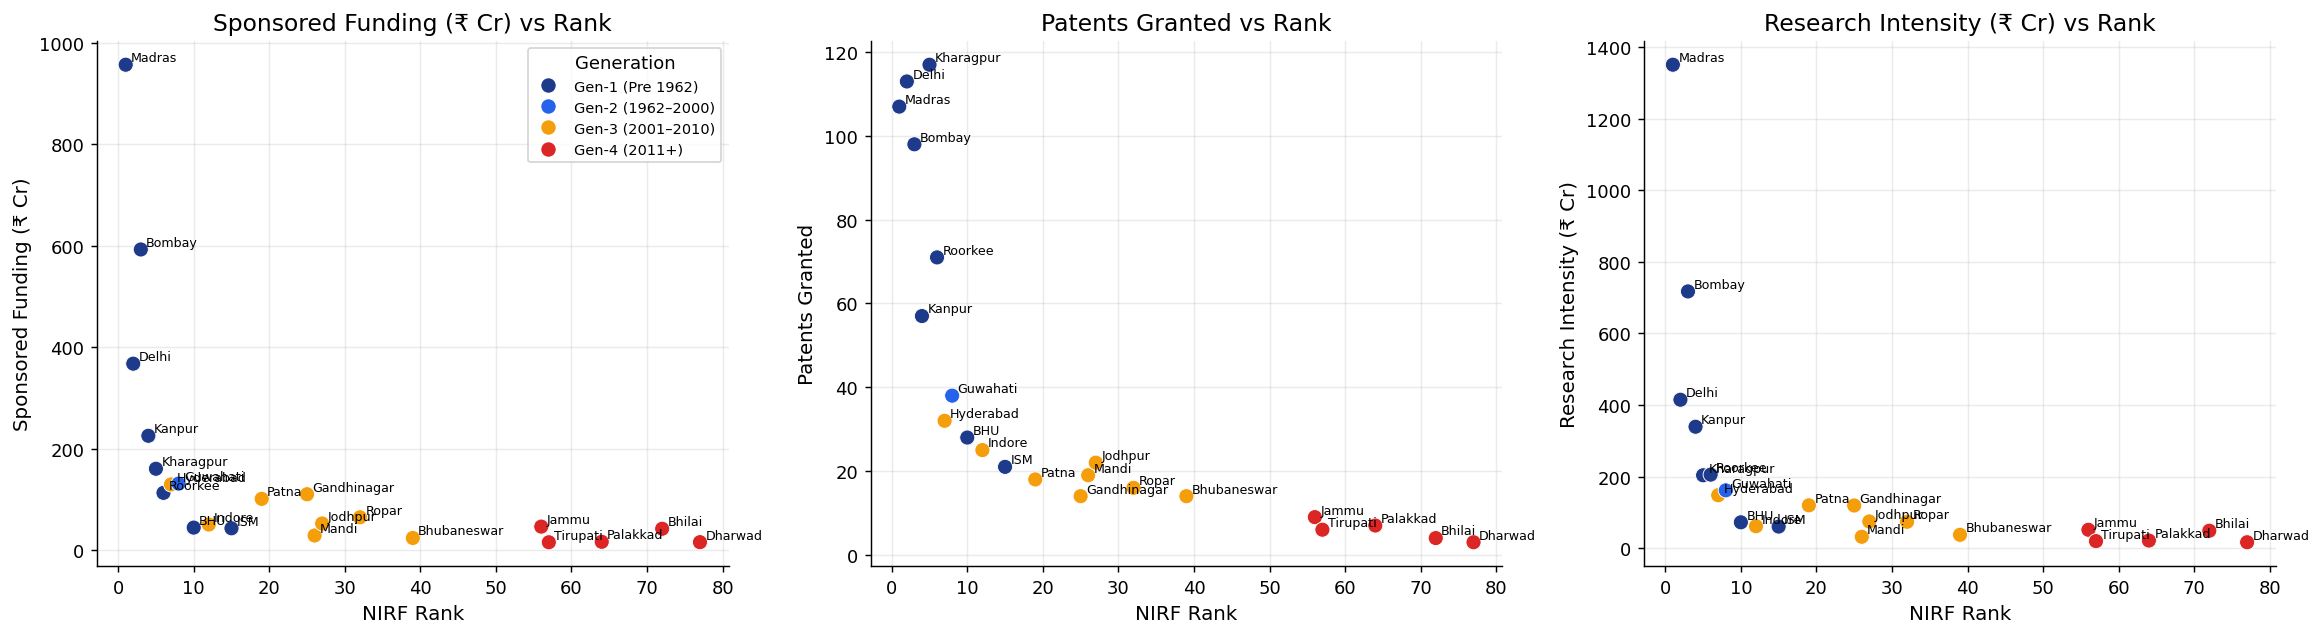

Saved: 05_research_patents_vs_rank.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
triplets = [
    ('sponsored_funding_cr', 'Sponsored Funding (₹ Cr)', '05_research_funding.png'),
    ('patents_granted',      'Patents Granted',           None),
    ('research_intensity_cr','Research Intensity (₹ Cr)', None),
]
for ax, (col, ylabel, _) in zip(axes, triplets):
    c = [GEN_COLORS[g] for g in master_s['generation']]
    ax.scatter(master_s['nirf_rank'], master_s[col], c=c, s=70,
               edgecolors='white', lw=0.5, zorder=3)
    for _, row in master_s.iterrows():
        ax.annotate(row['label'], (row['nirf_rank'], row[col]),
                    textcoords='offset points', xytext=(3, 2), fontsize=7)
    ax.set(xlabel='NIRF Rank', ylabel=ylabel, title=f'{ylabel} vs Rank')
    ax.grid(alpha=0.25)

handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,
                   markersize=9,label=GEN_LABELS[g])
           for g,c in GEN_COLORS.items()]
axes[0].legend(handles=handles, title='Generation', fontsize=8)
plt.tight_layout()
plt.savefig('05_research_patents_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 05_research_patents_vs_rank.png')

### 1.6  Radar Chart — Top-5 IITs Profile

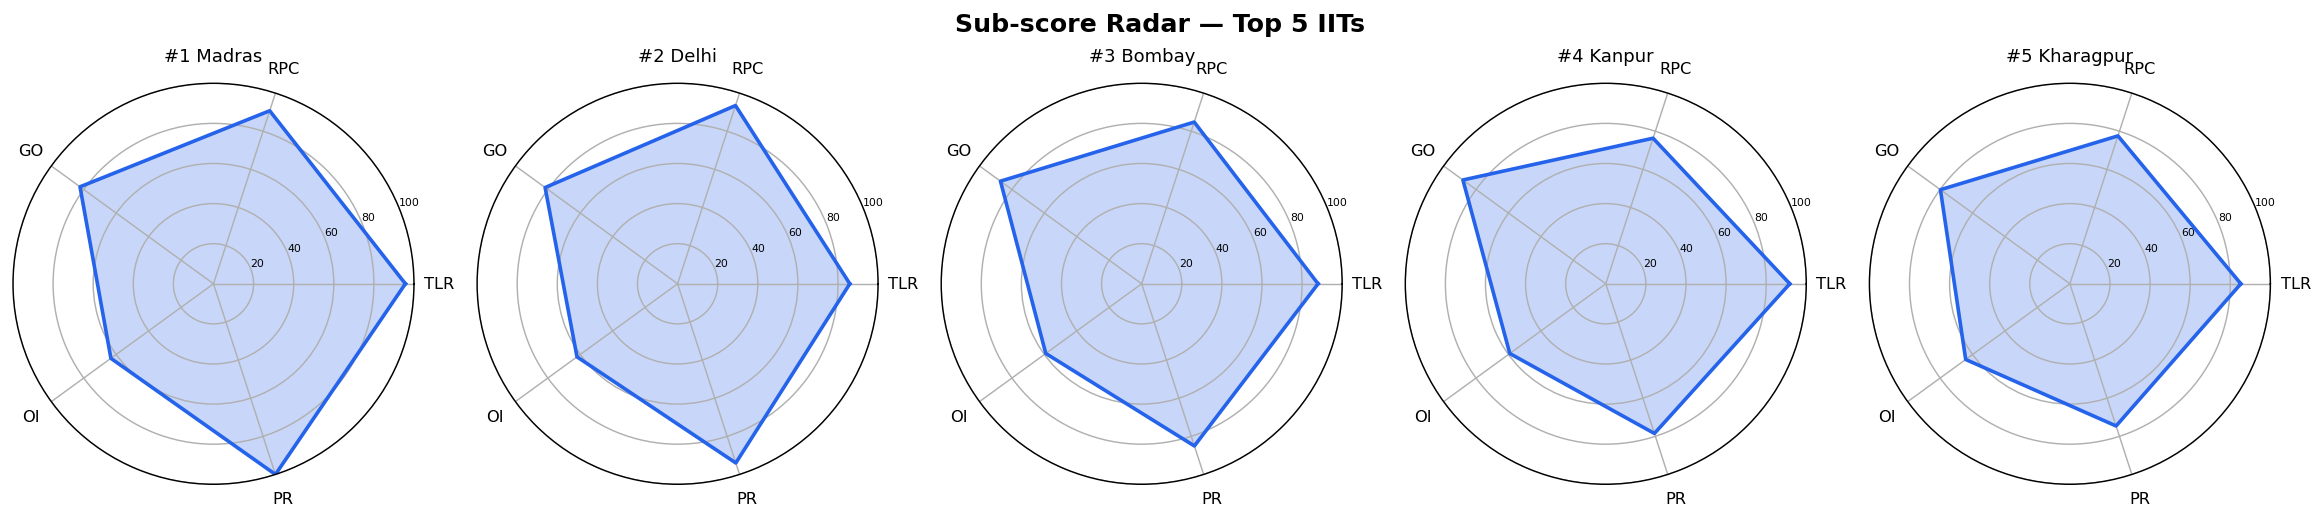

Saved: 06_radar_top5.png


In [8]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

radar_cols = ['tlr_score', 'rpc_score', 'go_score', 'oi_score', 'perception_score']
radar_labels = ['TLR', 'RPC', 'GO', 'OI', 'PR']
top5 = master_s.head(5)

angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4),
                          subplot_kw=dict(polar=True))
fig.suptitle('Sub-score Radar — Top 5 IITs', fontsize=14, fontweight='bold')

for ax, (_, row) in zip(axes, top5.iterrows()):
    vals = row[radar_cols].tolist() + [row[radar_cols[0]]]
    ax.plot(angles, vals, color=PALETTE[0], lw=2)
    ax.fill(angles, vals, color=PALETTE[0], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title(f"#{int(row['nirf_rank'])} {row['label']}",
                 fontsize=10, pad=12)
    ax.yaxis.set_tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('06_radar_top5.png', bbox_inches='tight')
plt.show()
print('Saved: 06_radar_top5.png')

---
## 2. Faculty Analysis

### 2.1  Faculty Age-Group Distribution — All IITs (Stacked Bar)

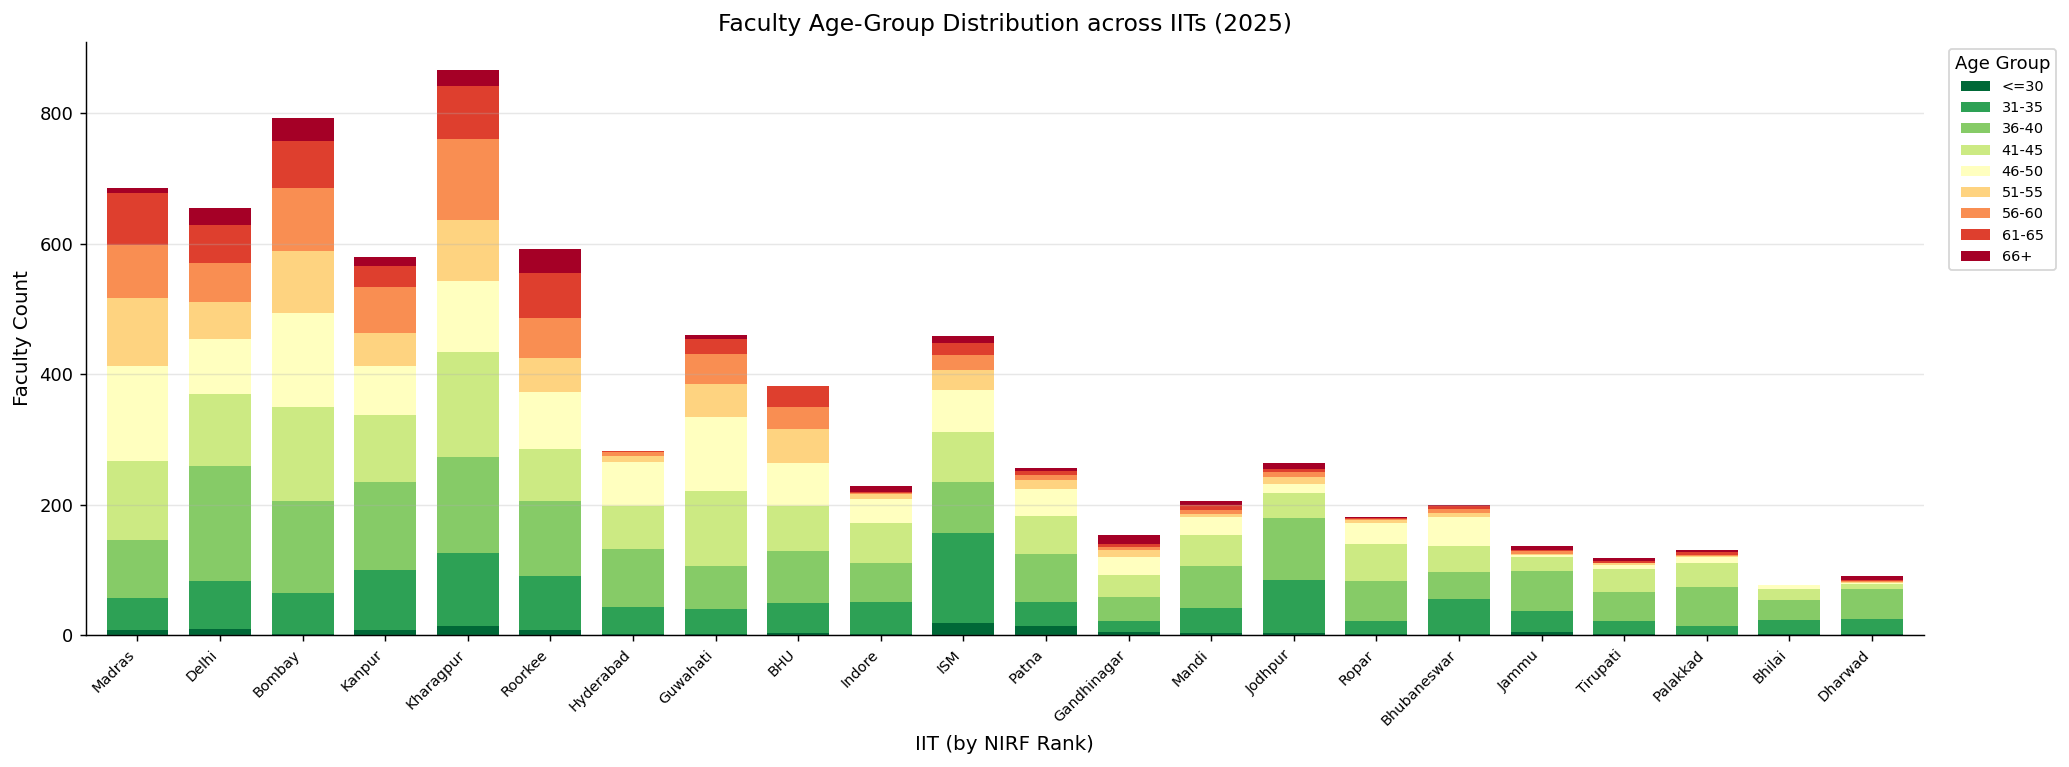

Saved: 07_faculty_age_stacked.png


In [9]:
age_order = ['<=30','31-35','36-40','41-45','46-50','51-55','56-60','61-65','66+']

# Pivot
age_pivot = age_grp.pivot_table(index='short_name', columns='age_group',
                                 values='faculty_count', aggfunc='sum').fillna(0)
age_pivot = age_pivot[age_order]

# Merge rank for sorting
rank_map = master.set_index('short_name')['nirf_rank']
age_pivot = age_pivot.loc[age_pivot.index.intersection(rank_map.index)]
age_pivot['_rank'] = age_pivot.index.map(rank_map)
age_pivot = age_pivot.sort_values('_rank').drop(columns='_rank')
labels_short = [s.replace('IIT ','') for s in age_pivot.index]

cmap = plt.cm.get_cmap('RdYlGn_r', len(age_order))
age_colors = [cmap(i) for i in range(len(age_order))]

fig, ax = plt.subplots(figsize=(16, 6))
age_pivot.plot(kind='bar', stacked=True, ax=ax, color=age_colors, width=0.75)
ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set(xlabel='IIT (by NIRF Rank)', ylabel='Faculty Count',
       title='Faculty Age-Group Distribution across IITs (2025)')
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('07_faculty_age_stacked.png', bbox_inches='tight')
plt.show()
print('Saved: 07_faculty_age_stacked.png')

### 2.2  Faculty Age Distribution — Gen1 vs Gen4 Comparison

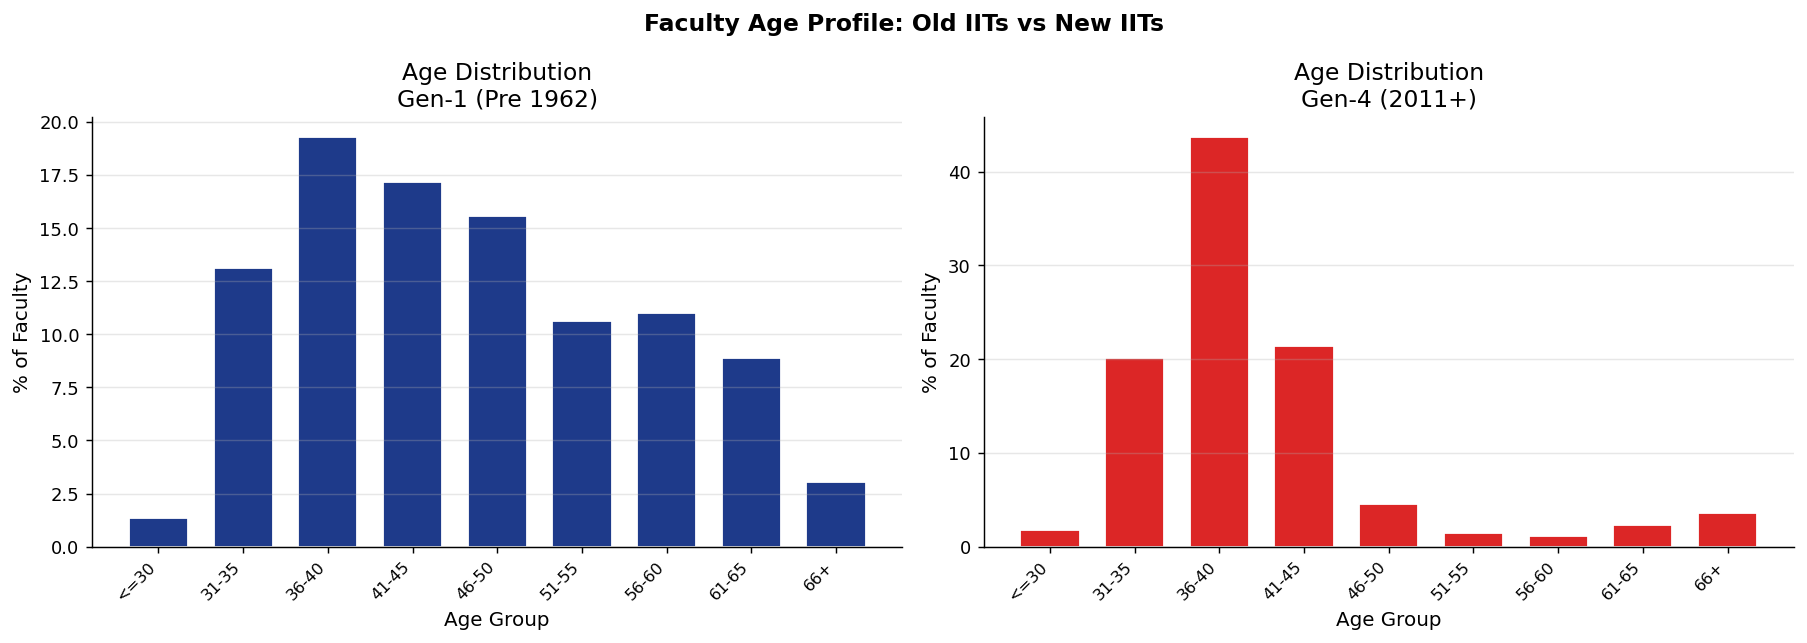

Saved: 08_faculty_age_gen_compare.png


In [10]:
gen_map = master.set_index('short_name')['generation']
age_grp2 = age_grp.copy()
age_grp2['generation'] = age_grp2['short_name'].map(gen_map)

gen_age = age_grp2.groupby(['generation','age_group'])['faculty_count'].sum().reset_index()
# Normalise within each generation
gen_total = gen_age.groupby('generation')['faculty_count'].transform('sum')
gen_age['pct'] = gen_age['faculty_count'] / gen_total * 100

gen_age['age_group'] = pd.Categorical(gen_age['age_group'], categories=age_order, ordered=True)
gen_age = gen_age.sort_values(['generation','age_group'])

gens = ['Gen1_Pre1962', 'Gen4_2011_plus']
gen_labels_short = ['Gen-1 (Pre 1962)', 'Gen-4 (2011+)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, gen, glabel in zip(axes, gens, gen_labels_short):
    sub = gen_age[gen_age['generation']==gen]
    clrs = [GEN_COLORS[gen]] * len(sub)
    ax.bar(sub['age_group'], sub['pct'], color=clrs, edgecolor='white', width=0.7)
    ax.set(xlabel='Age Group', ylabel='% of Faculty',
           title=f'Age Distribution\n{glabel}')
    ax.set_xticklabels(sub['age_group'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Faculty Age Profile: Old IITs vs New IITs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_faculty_age_gen_compare.png', bbox_inches='tight')
plt.show()
print('Saved: 08_faculty_age_gen_compare.png')

### 2.3  Faculty Joining-Period Distribution — Heatmap

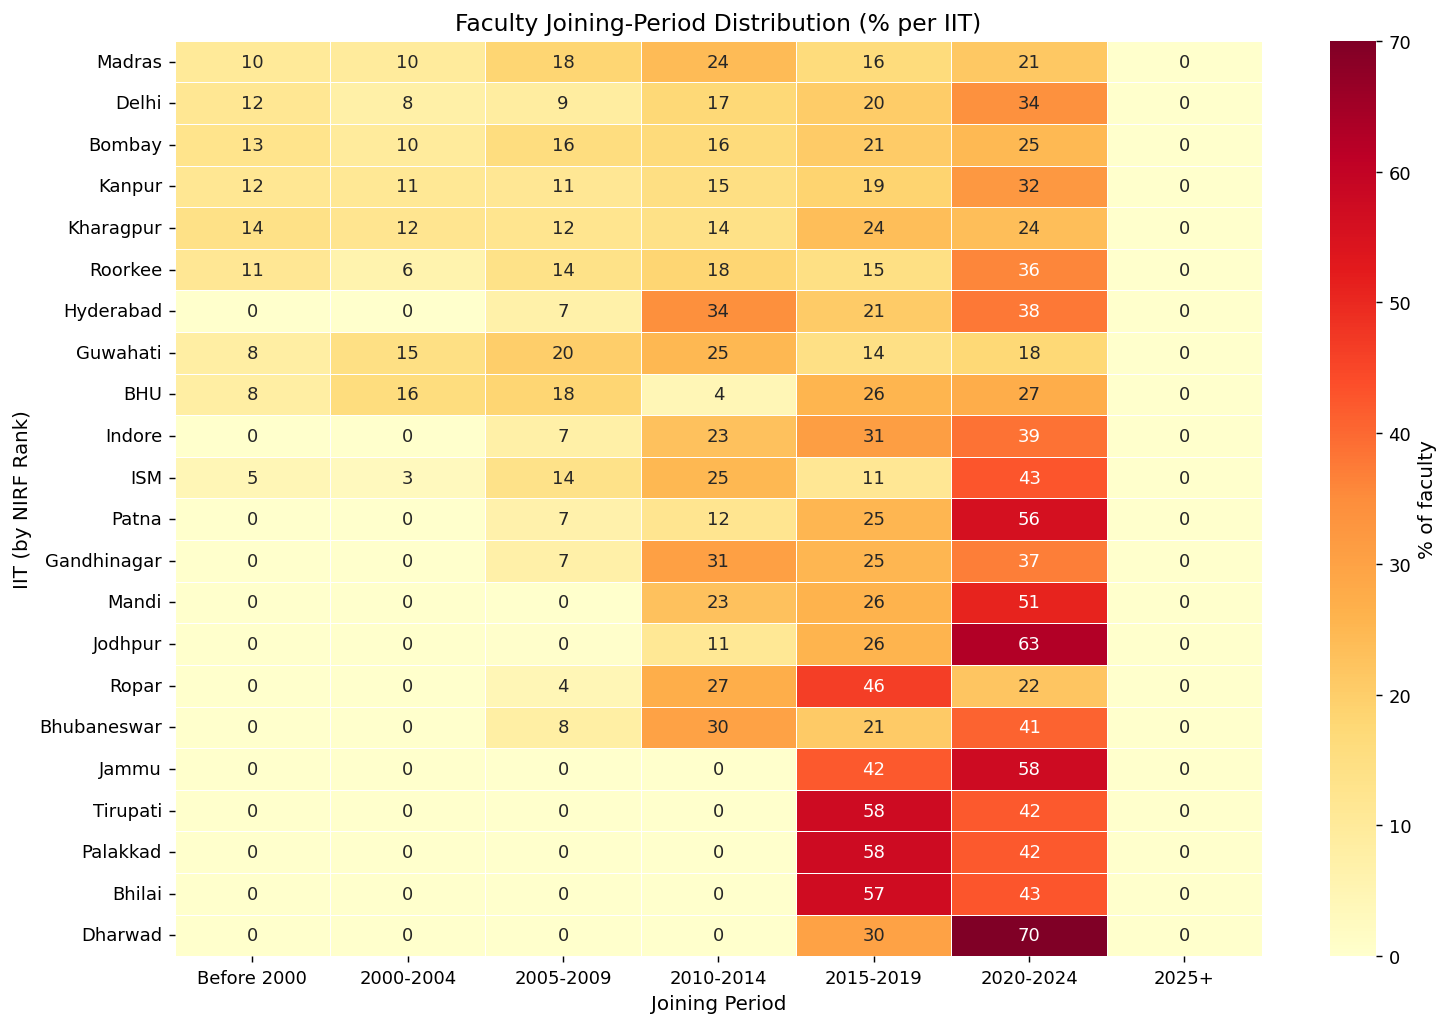

Saved: 09_joining_heatmap.png


In [11]:
join_order = ['Before 2000','2000-2004','2005-2009','2010-2014','2015-2019','2020-2024','2025+']

join_pivot = join_per.pivot_table(index='short_name', columns='joining_period',
                                   values='faculty_count', aggfunc='sum').fillna(0)
# keep only columns present
cols_present = [c for c in join_order if c in join_pivot.columns]
join_pivot = join_pivot[cols_present]
join_pivot['_rank'] = join_pivot.index.map(rank_map)
join_pivot = join_pivot.sort_values('_rank').drop(columns='_rank')
join_pivot.index = [s.replace('IIT ','') for s in join_pivot.index]

# normalise row-wise
join_pct = join_pivot.div(join_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(join_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': '% of faculty'})
ax.set(xlabel='Joining Period', ylabel='IIT (by NIRF Rank)',
       title='Faculty Joining-Period Distribution (% per IIT)')
plt.tight_layout()
plt.savefig('09_joining_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 09_joining_heatmap.png')

---
## 3. Correlation Analysis

### 3.1  Correlation Matrix (save CSV + heatmap)

correlation_matrix.csv saved ✓


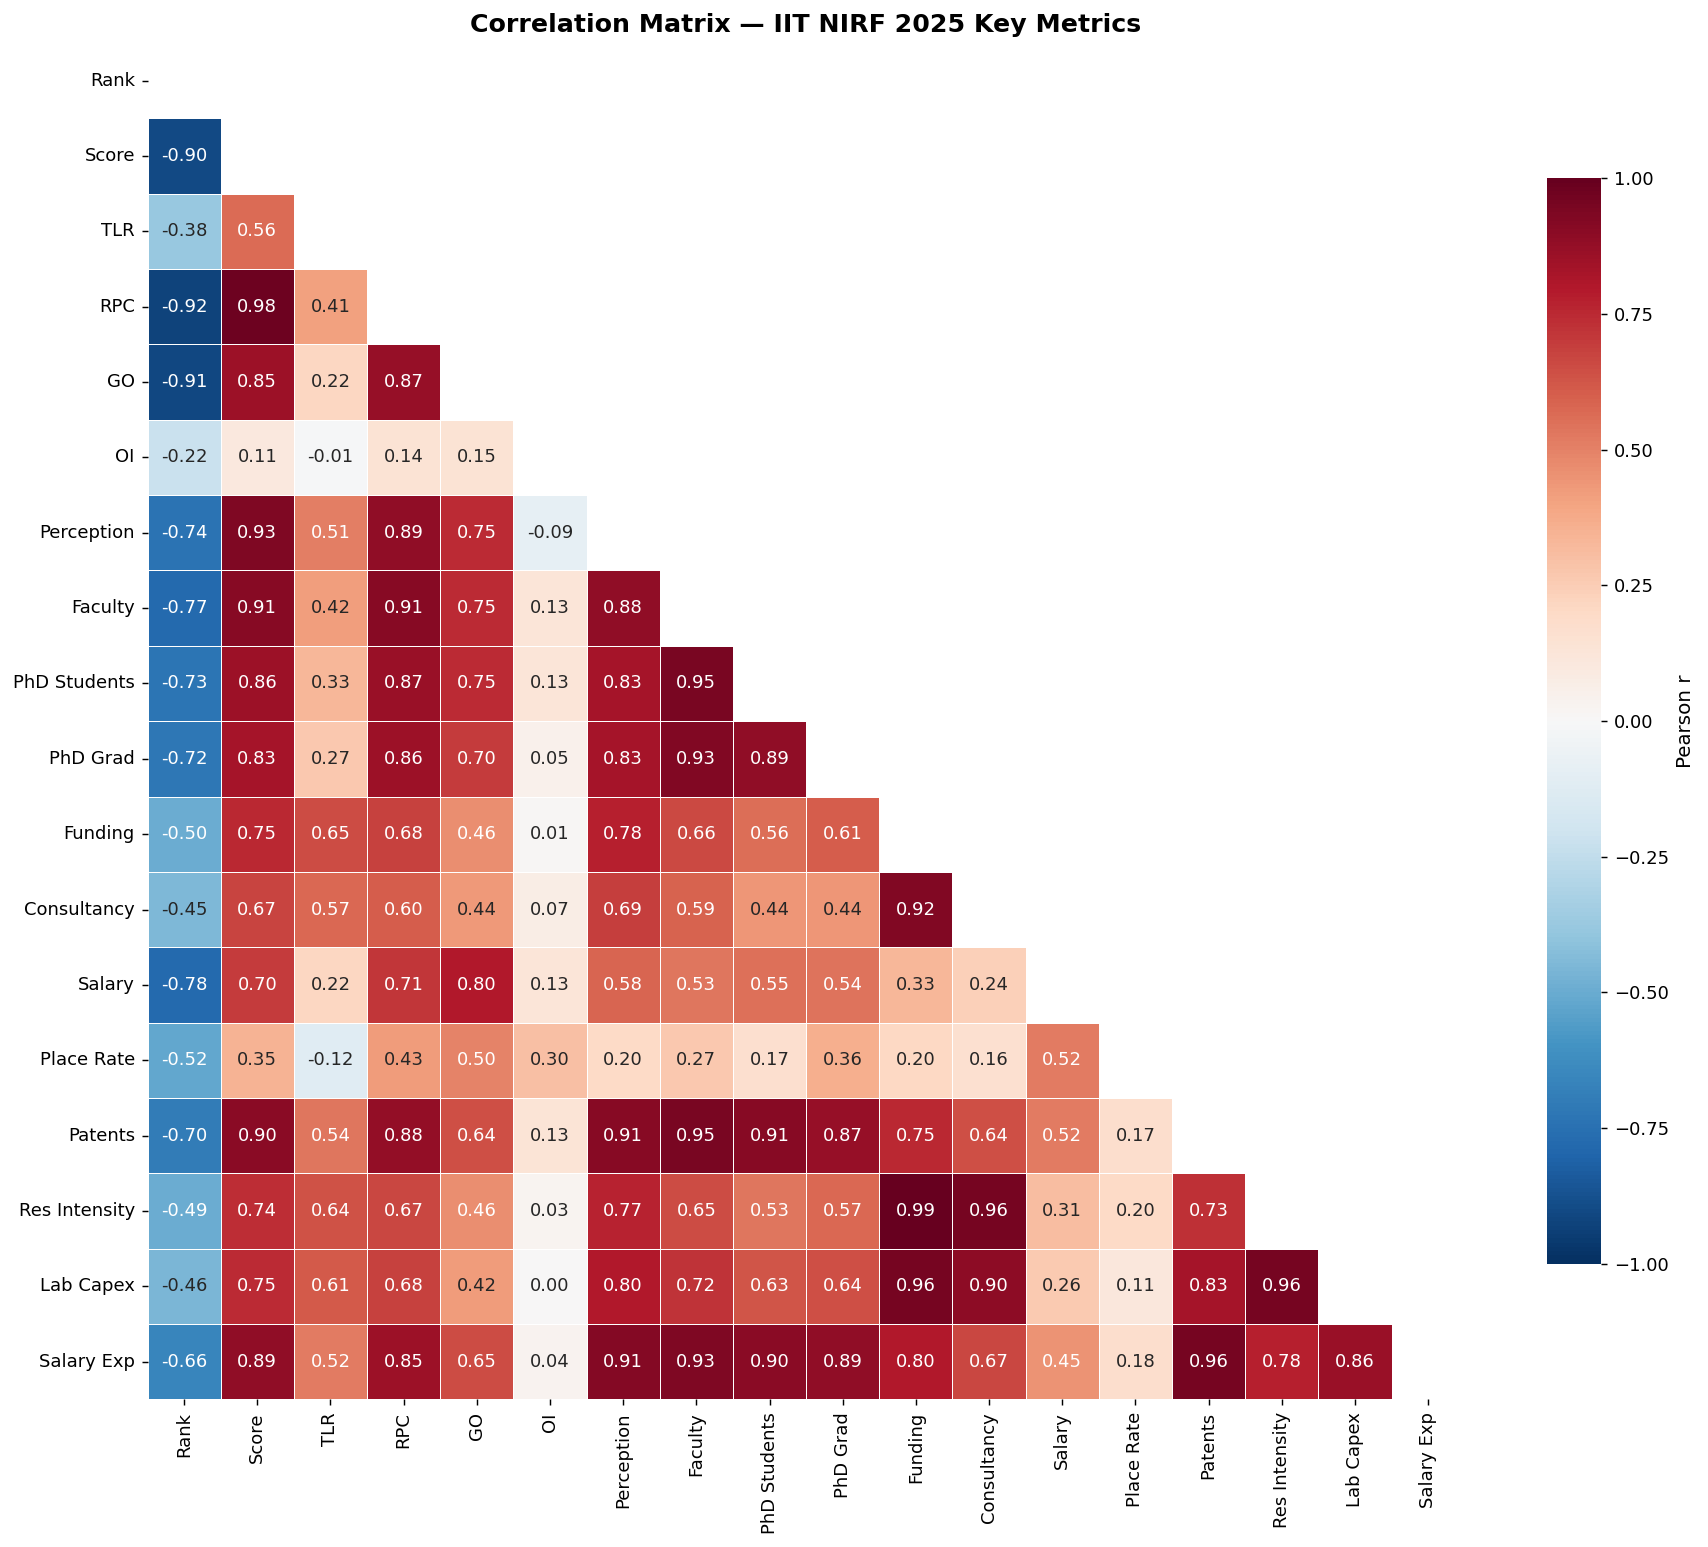

Saved: 10_correlation_heatmap.png


In [12]:
CORR_COLS = [
    'nirf_rank', 'nirf_score',
    'tlr_score', 'rpc_score', 'go_score', 'oi_score', 'perception_score',
    'total_faculty', 'phd_students_fulltime', 'phd_graduated_latest',
    'sponsored_funding_cr', 'consultancy_revenue_cr',
    'ug_median_salary_lakh', 'placement_rate_pct',
    'patents_granted', 'research_intensity_cr',
    'lab_capex_cr', 'salary_expense_cr'
]

corr_df = master[CORR_COLS].corr()
corr_df.to_csv('correlation_matrix.csv')
print('correlation_matrix.csv saved ✓')

NICE_NAMES = {
    'nirf_rank':'Rank','nirf_score':'Score',
    'tlr_score':'TLR','rpc_score':'RPC','go_score':'GO',
    'oi_score':'OI','perception_score':'Perception',
    'total_faculty':'Faculty','phd_students_fulltime':'PhD Students',
    'phd_graduated_latest':'PhD Grad','sponsored_funding_cr':'Funding',
    'consultancy_revenue_cr':'Consultancy','ug_median_salary_lakh':'Salary',
    'placement_rate_pct':'Place Rate','patents_granted':'Patents',
    'research_intensity_cr':'Res Intensity','lab_capex_cr':'Lab Capex',
    'salary_expense_cr':'Salary Exp'
}
corr_display = corr_df.rename(index=NICE_NAMES, columns=NICE_NAMES)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_display, dtype=bool))
sns.heatmap(corr_display, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation Matrix — IIT NIRF 2025 Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 10_correlation_heatmap.png')

### 3.2  Rank Drivers — Bar Chart of |correlation with nirf_rank|

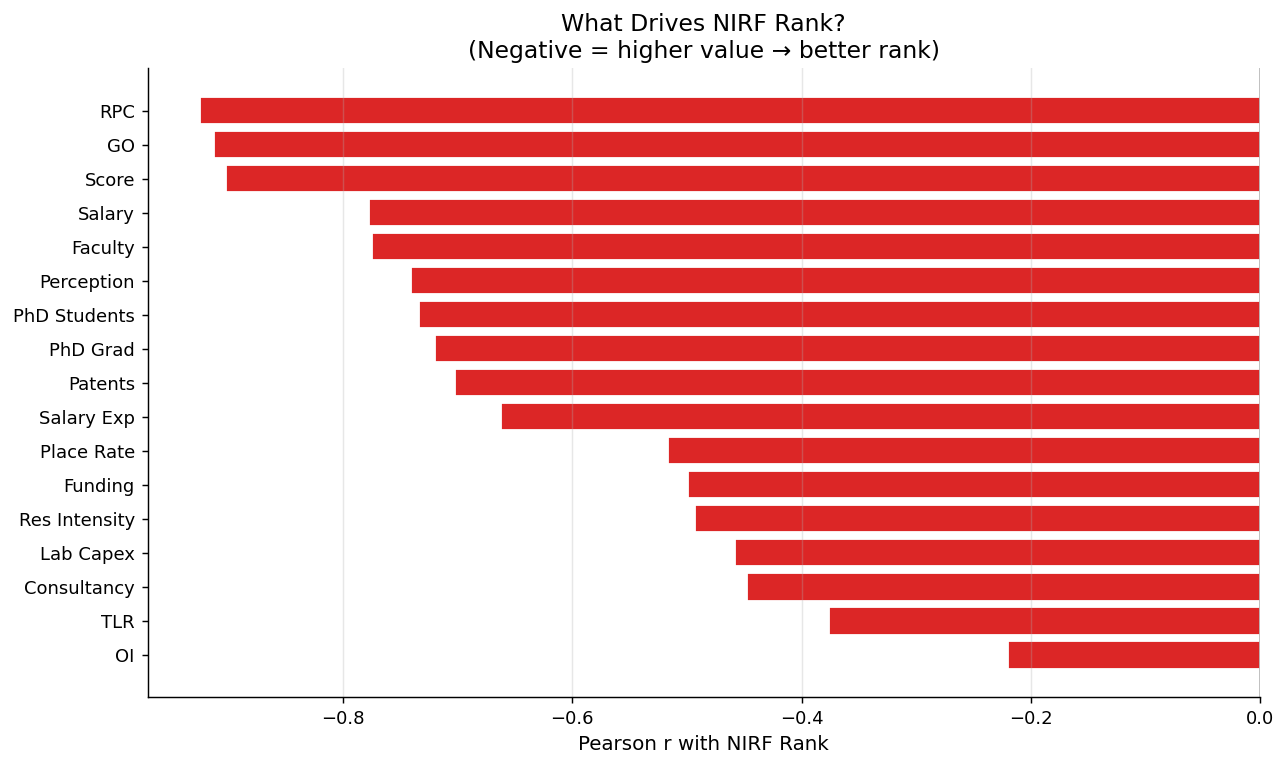

Saved: 11_rank_drivers.png


In [13]:
rank_corr = corr_df['nirf_rank'].drop('nirf_rank').sort_values(key=abs, ascending=False)
nice_idx = [NICE_NAMES.get(c, c) for c in rank_corr.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#DC2626' if v < 0 else '#16A34A' for v in rank_corr.values]
ax.barh(nice_idx[::-1], rank_corr.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set(xlabel="Pearson r with NIRF Rank",
       title="What Drives NIRF Rank?\n(Negative = higher value → better rank)")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('11_rank_drivers.png', bbox_inches='tight')
plt.show()
print('Saved: 11_rank_drivers.png')

### 3.3  Pair Plot — Score, Funding, Salary, Perception, Rank

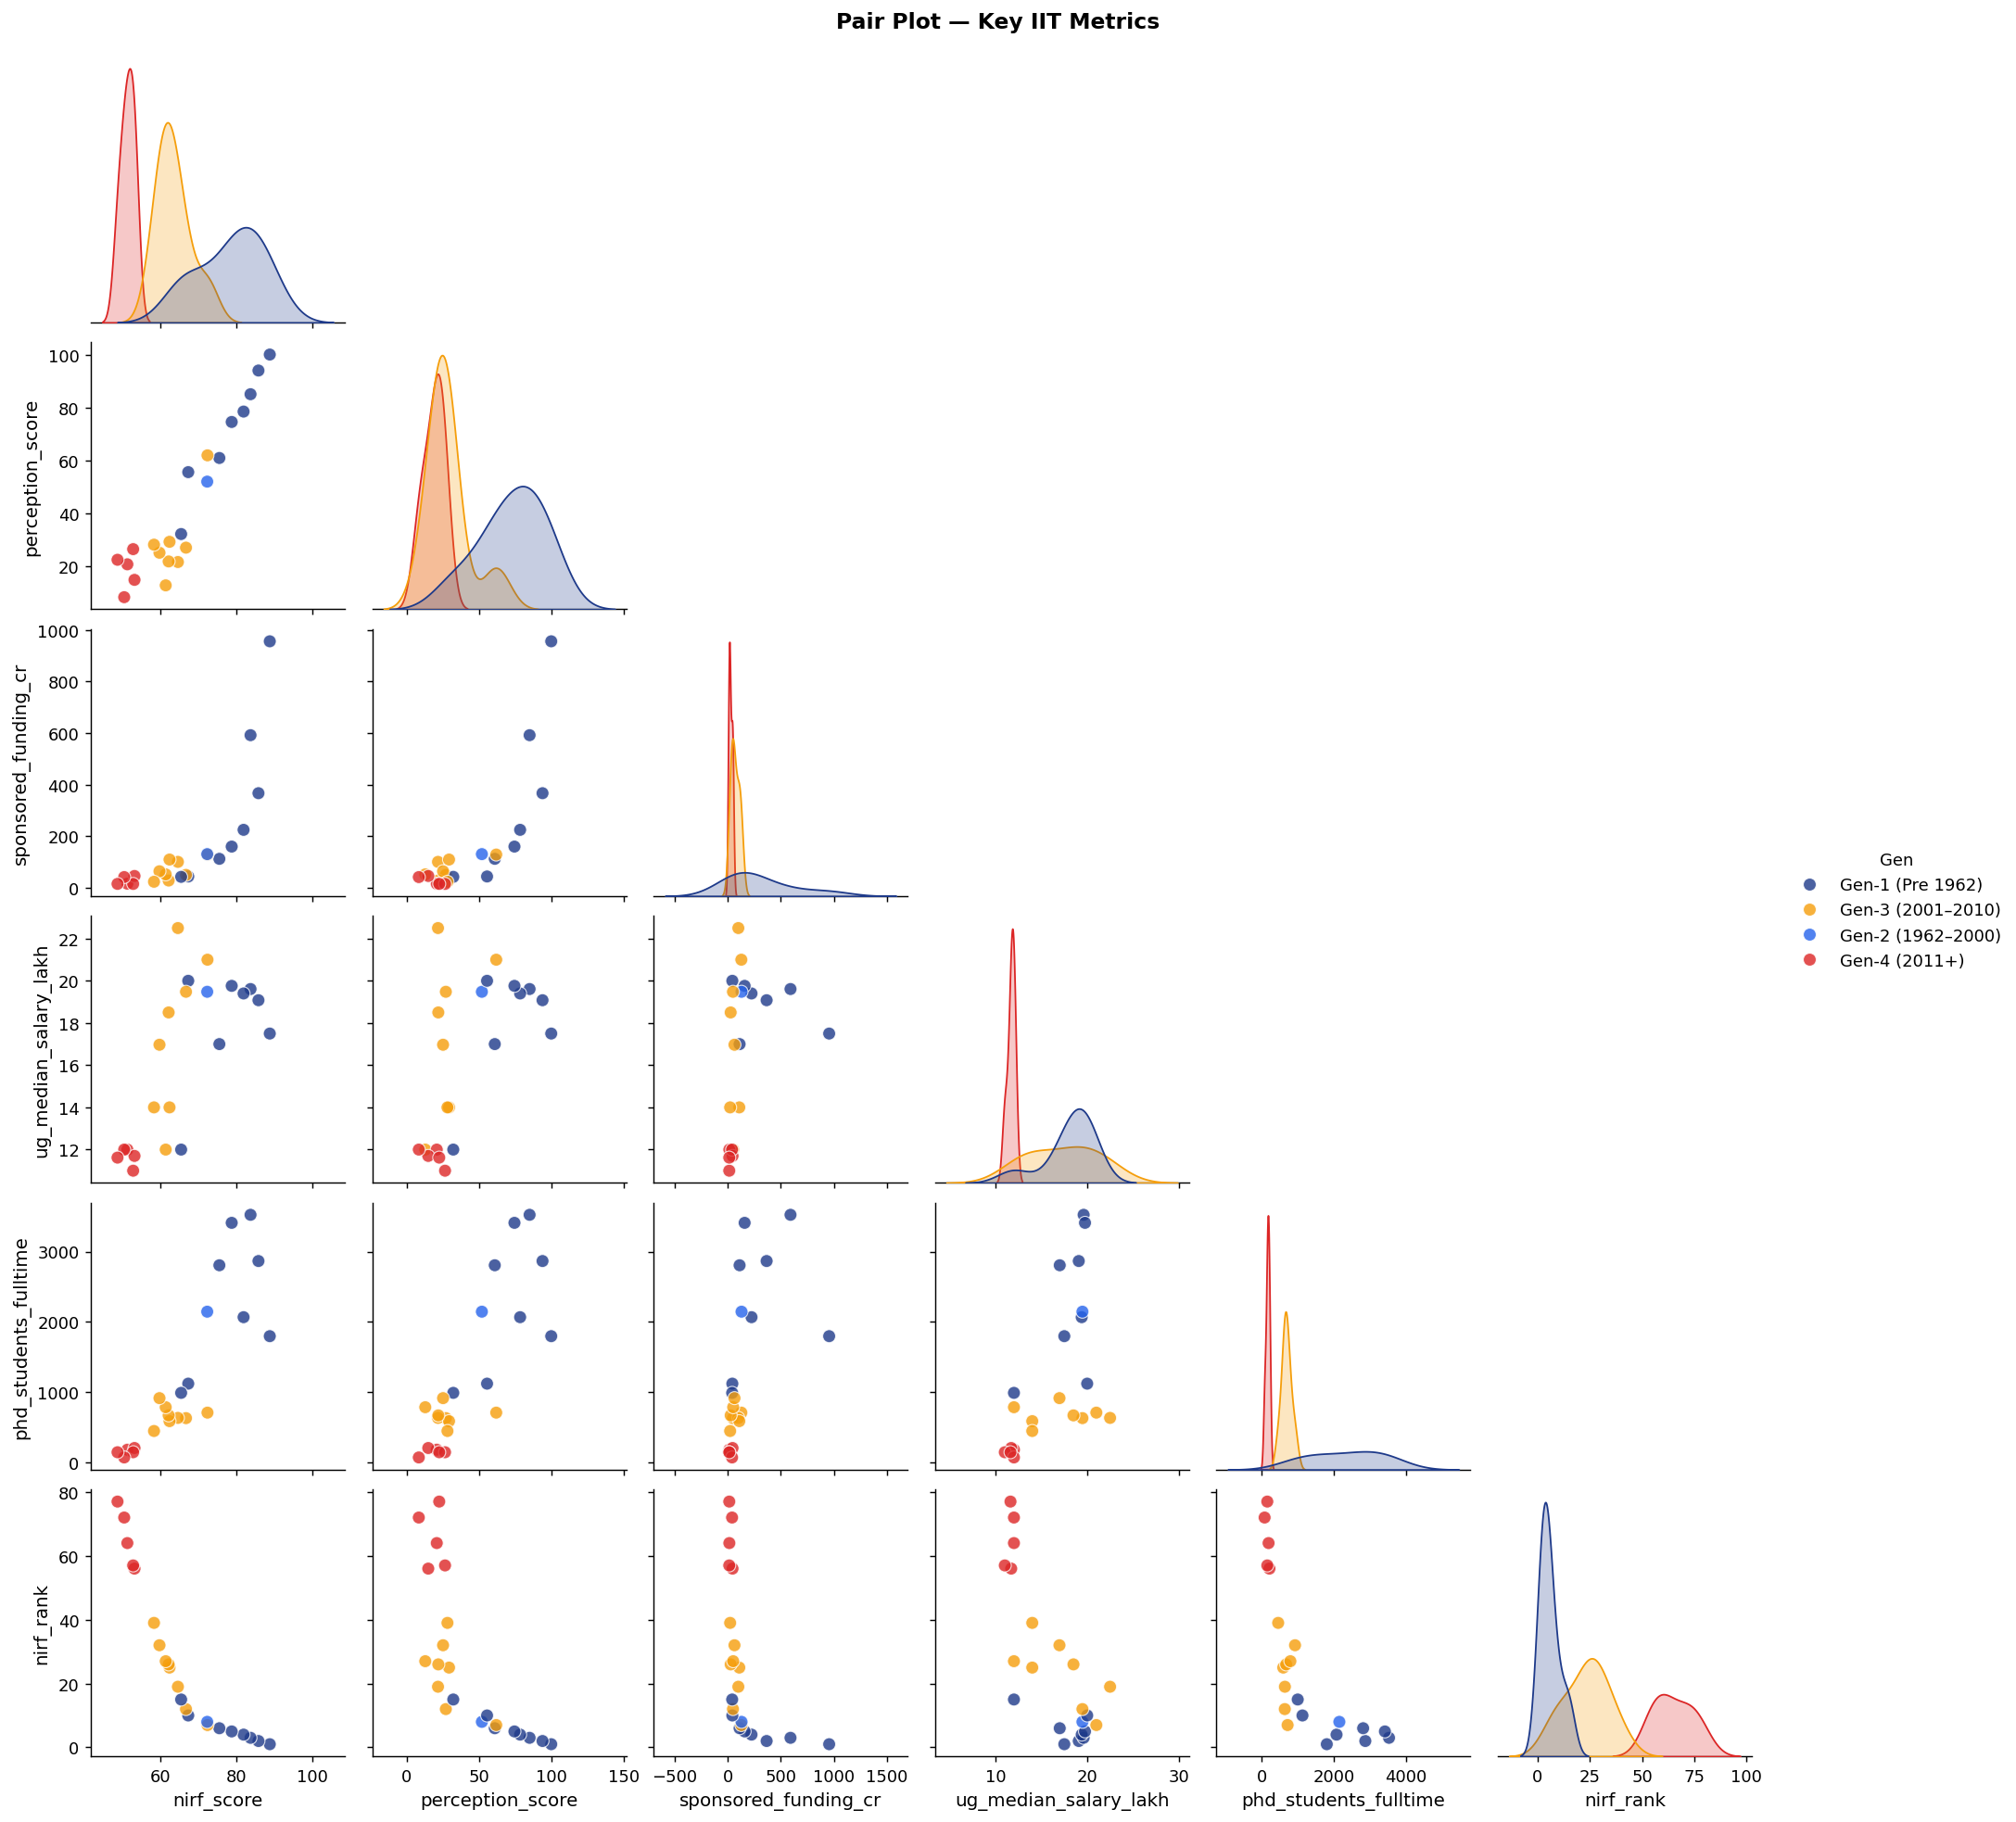

Saved: 12_pairplot.png


In [14]:
pair_cols = ['nirf_score','perception_score','sponsored_funding_cr',
             'ug_median_salary_lakh','phd_students_fulltime','nirf_rank']
pair_df = master[pair_cols + ['generation']].dropna()
pair_df['Gen'] = pair_df['generation'].map(GEN_LABELS)

g = sns.pairplot(pair_df.drop(columns='generation'),
                 hue='Gen',
                 palette={v: GEN_COLORS[k] for k, v in GEN_LABELS.items()},
                 plot_kws={'alpha': 0.8, 's': 60},
                 diag_kind='kde',
                 corner=True)
g.figure.suptitle('Pair Plot — Key IIT Metrics', y=1.01, fontsize=13, fontweight='bold')
g.figure.savefig('12_pairplot.png', bbox_inches='tight')
plt.show()
print('Saved: 12_pairplot.png')

---
## 4. PCA — Dimensionality Reduction

### 4.1  Prepare & Scale Features

IITs used for PCA/Clustering: 22


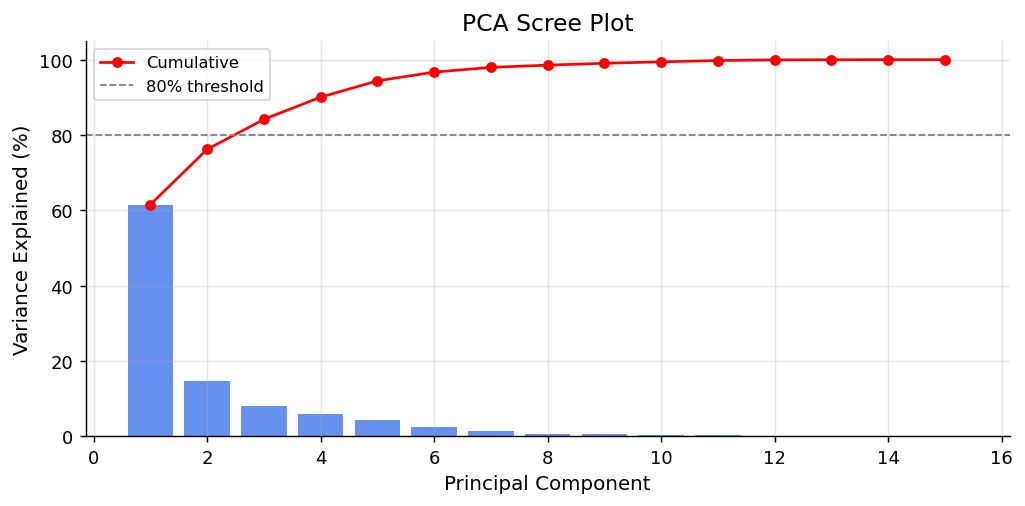

In [15]:
PCA_FEATURES = [
    'tlr_score', 'rpc_score', 'go_score', 'oi_score', 'perception_score',
    'total_faculty', 'phd_students_fulltime', 'phd_graduated_latest',
    'sponsored_funding_cr', 'consultancy_revenue_cr',
    'ug_median_salary_lakh', 'placement_rate_pct',
    'patents_granted', 'research_intensity_cr',
    'lab_capex_cr',
]

pca_df = master[['short_name','label','nirf_rank','generation'] + PCA_FEATURES].dropna().copy()
print(f'IITs used for PCA/Clustering: {len(pca_df)}')

X = pca_df[PCA_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Full PCA for variance explained
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='#2563EB', alpha=0.7)
ax.plot(range(1, len(explained)+1), np.cumsum(explained)*100,
        'r-o', markersize=5, label='Cumulative')
ax.axhline(80, color='gray', lw=1, linestyle='--', label='80% threshold')
ax.set(xlabel='Principal Component', ylabel='Variance Explained (%)',
       title='PCA Scree Plot')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('13_pca_scree.png', bbox_inches='tight')
plt.show()

### 4.2  2D PCA Scatter — coloured by Generation

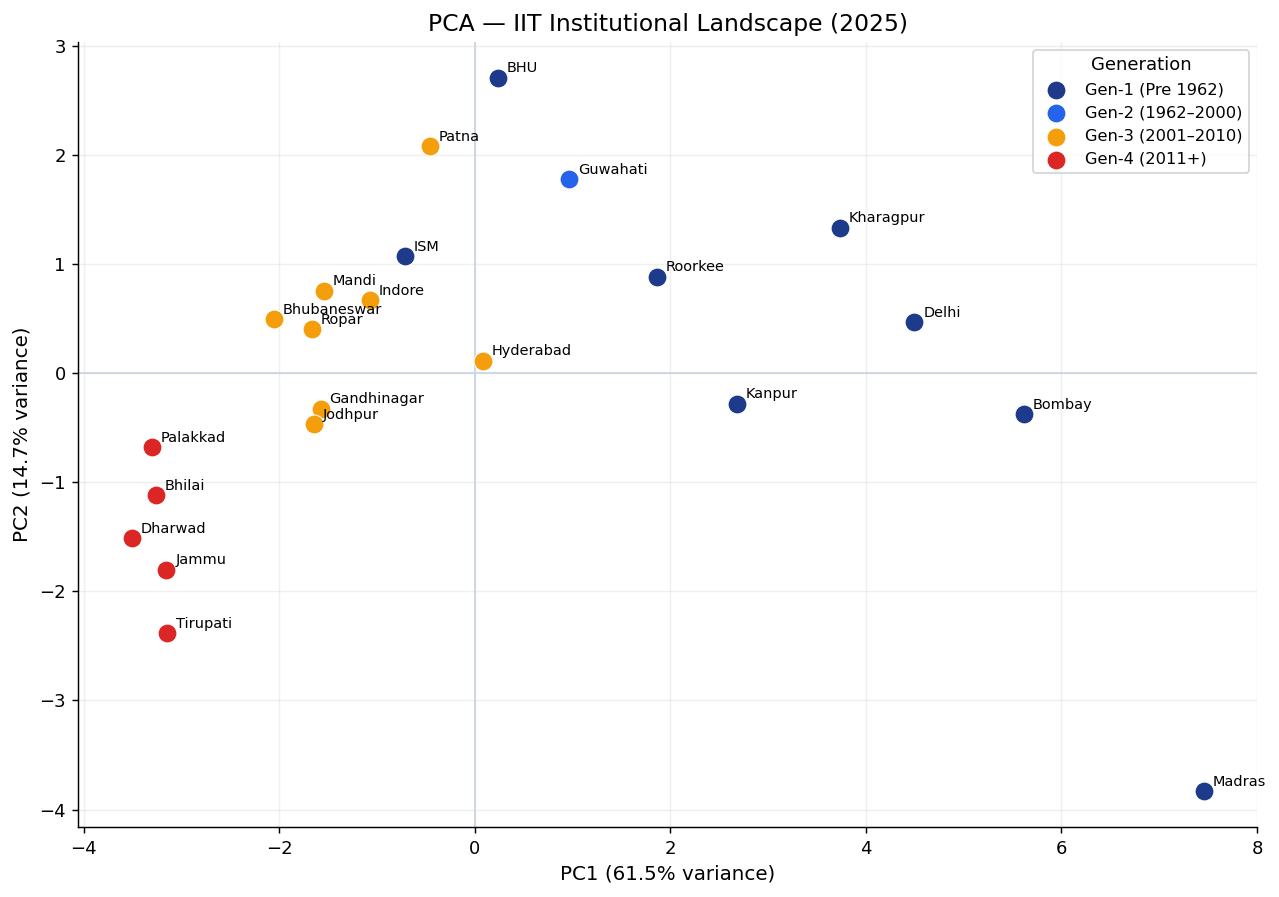

Saved: 14_pca_2d_generation.png


In [16]:
pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_scaled)
pca_df['PC1'] = coords[:, 0]
pca_df['PC2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for gen, sub in pca_df.groupby('generation'):
    ax.scatter(sub['PC1'], sub['PC2'],
               color=GEN_COLORS[gen], s=110,
               edgecolors='white', lw=0.6, zorder=3,
               label=GEN_LABELS[gen])
    for _, row in sub.iterrows():
        ax.annotate(row['label'], (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.axhline(0, color='#CBD5E1', lw=1)
ax.axvline(0, color='#CBD5E1', lw=1)
ax.set(
    xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)',
    ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)',
    title='PCA — IIT Institutional Landscape (2025)'
)
ax.legend(title='Generation', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('14_pca_2d_generation.png', bbox_inches='tight')
plt.show()
print('Saved: 14_pca_2d_generation.png')

### 4.3  PCA Loadings Biplot

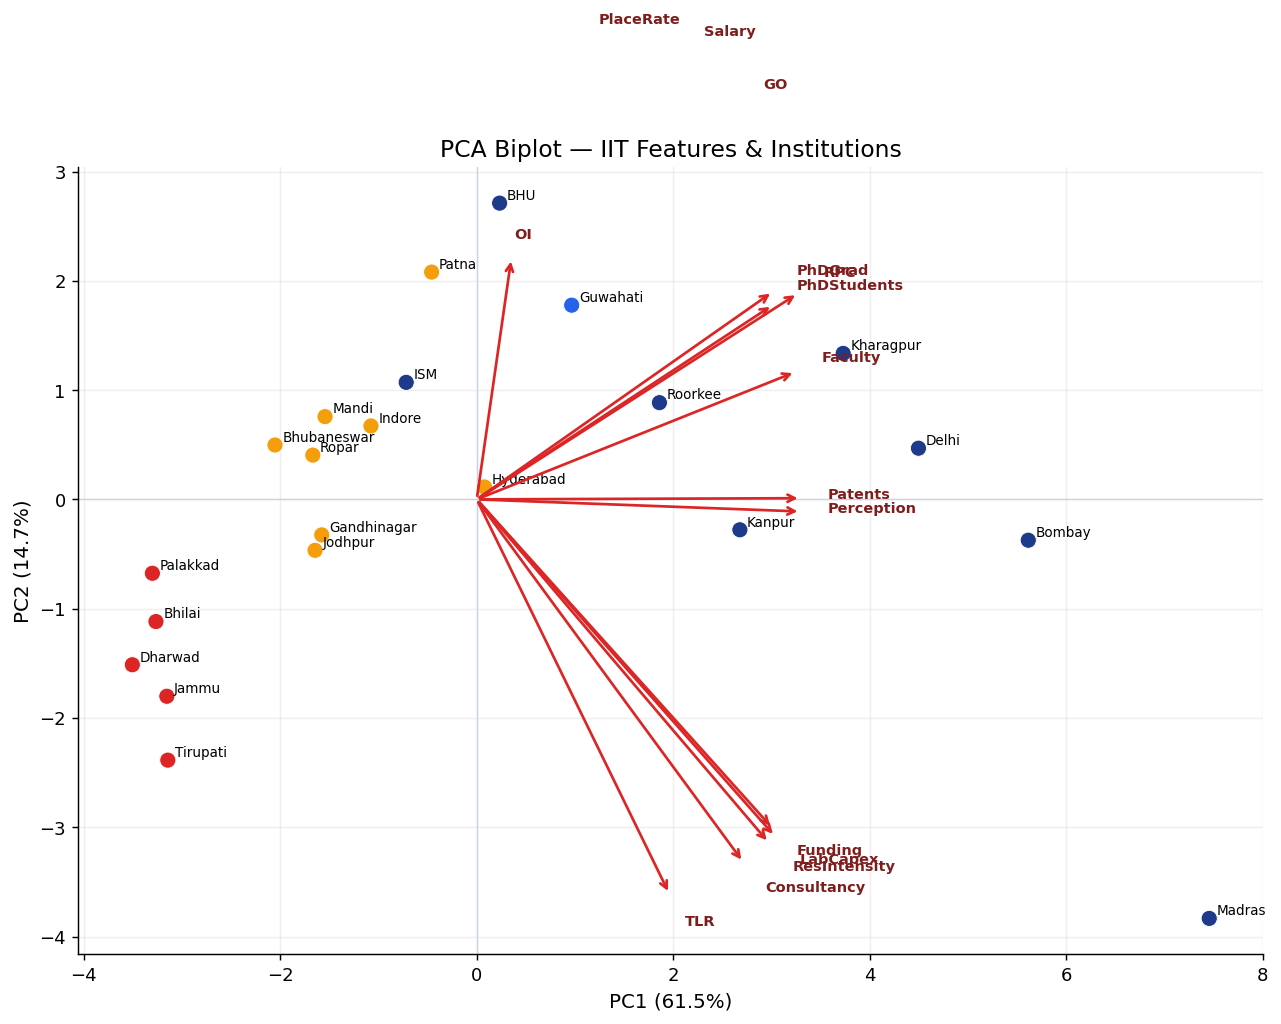

Saved: 15_pca_biplot.png


In [17]:
loadings = pca2.components_.T  # (n_features, 2)
feat_labels = [
    'TLR','RPC','GO','OI','Perception',
    'Faculty','PhDStudents','PhDGrad',
    'Funding','Consultancy',
    'Salary','PlaceRate',
    'Patents','ResIntensity','LabCapex'
]

fig, ax = plt.subplots(figsize=(10, 8))
# scatter IITs
scale = max(abs(coords[:, 0]).max(), abs(coords[:, 1]).max())
lscale = scale / max(np.sqrt(loadings[:,0]**2 + loadings[:,1]**2)) * 0.6
c = [GEN_COLORS[g] for g in pca_df['generation']]
ax.scatter(coords[:,0], coords[:,1], c=c, s=80, zorder=3, edgecolors='white', lw=0.5)
for i, row in pca_df.iterrows():
    ax.annotate(row['label'], (row['PC1'], row['PC2']),
                textcoords='offset points', xytext=(4,2), fontsize=7.5)
# arrows
for i, (fl, lv) in enumerate(zip(feat_labels, loadings)):
    ax.annotate('', xy=(lv[0]*lscale, lv[1]*lscale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.5))
    ax.text(lv[0]*lscale*1.08, lv[1]*lscale*1.08, fl,
            color='#7F1D1D', fontsize=8, fontweight='bold')

ax.axhline(0, color='#CBD5E1', lw=0.8)
ax.axvline(0, color='#CBD5E1', lw=0.8)
ax.set(xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)',
       title='PCA Biplot — IIT Features & Institutions')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('15_pca_biplot.png', bbox_inches='tight')
plt.show()
print('Saved: 15_pca_biplot.png')

---
## 5. K-Means Clustering

### 5.1  Elbow Method + Silhouette Scores

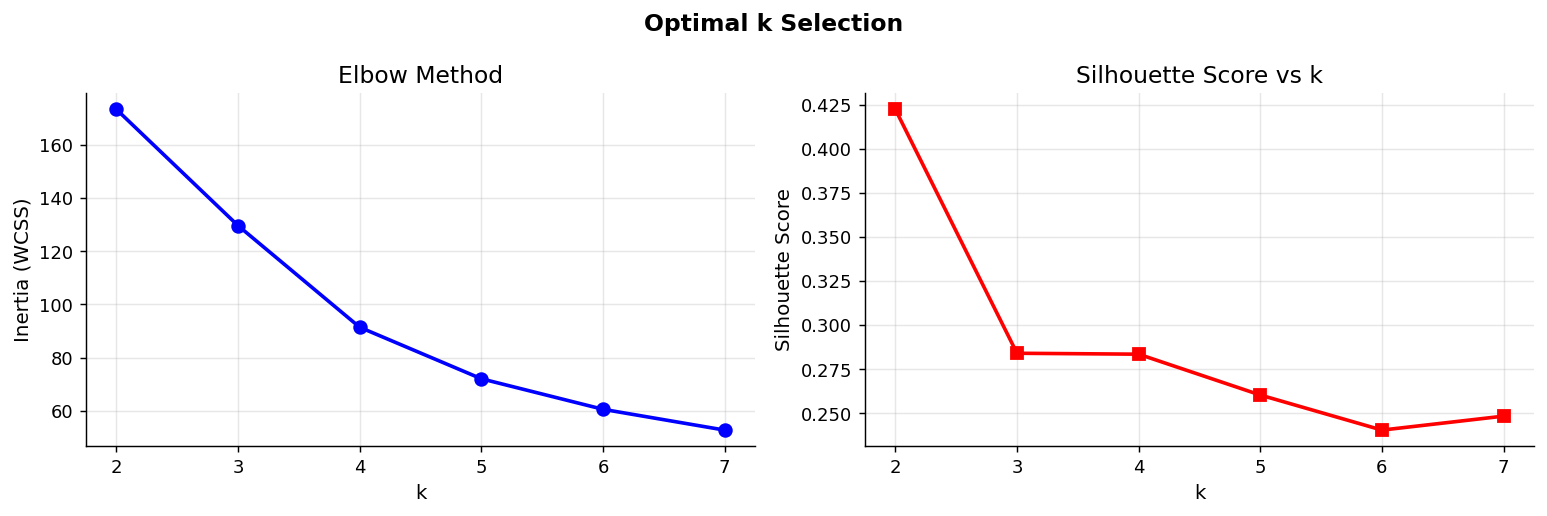

Best k (silhouette): 2


In [18]:
inertia, sil = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertia, 'bo-', lw=2, markersize=7)
ax1.set(xlabel='k', ylabel='Inertia (WCSS)', title='Elbow Method')
ax1.grid(alpha=0.3)

ax2.plot(list(K_range), sil, 'rs-', lw=2, markersize=7)
ax2.set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Score vs k')
ax2.grid(alpha=0.3)

plt.suptitle('Optimal k Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('16_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print('Best k (silhouette):', list(K_range)[np.argmax(sil)])

### 5.2  KMeans k=3 — Research-heavy / Balanced / Emerging

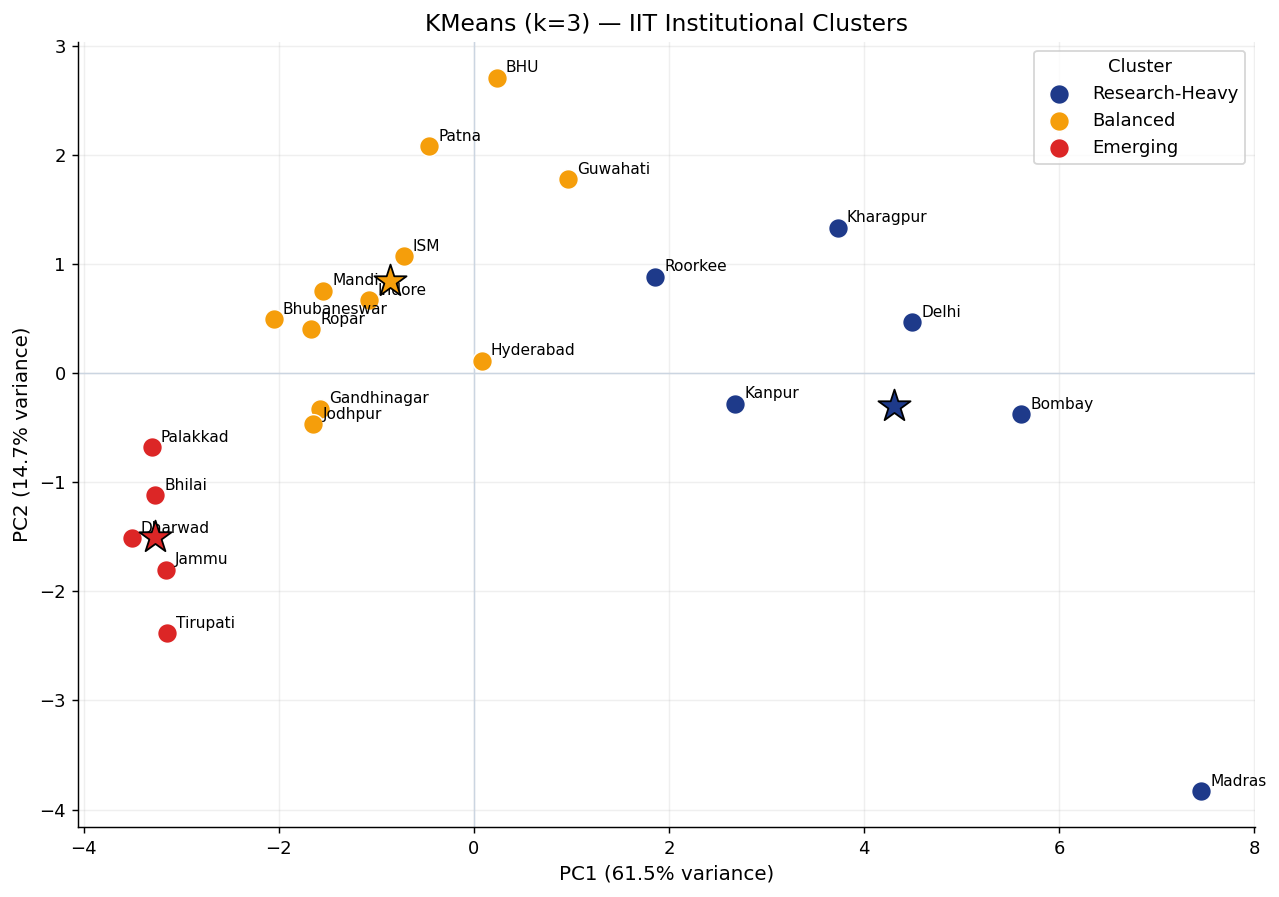

Saved: 17_kmeans_k3.png


In [19]:
CLUSTER_PALETTE_3 = ['#1E3A8A', '#F59E0B', '#DC2626']

km3 = KMeans(n_clusters=3, random_state=42, n_init=20)
pca_df['cluster_k3'] = km3.fit_predict(X_scaled)

# ── label clusters by mean NIRF score
mean_score = pca_df.groupby('cluster_k3')['nirf_rank'].mean().sort_values()
rank_order = mean_score.index.tolist()
cluster_names_3 = {rank_order[0]: 'Research-Heavy',
                   rank_order[1]: 'Balanced',
                   rank_order[2]: 'Emerging'}
pca_df['cluster_k3_label'] = pca_df['cluster_k3'].map(cluster_names_3)

# Scatter on PCA space
fig, ax = plt.subplots(figsize=(10, 7))
for cid, cname in cluster_names_3.items():
    sub = pca_df[pca_df['cluster_k3'] == cid]
    ax.scatter(sub['PC1'], sub['PC2'], s=120,
               color=CLUSTER_PALETTE_3[rank_order.index(cid)],
               edgecolors='white', lw=0.8, zorder=3, label=cname)
    for _, row in sub.iterrows():
        ax.annotate(row['label'], (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8.5)

# Cluster centroids in PCA space
centers_pca = pca2.transform(km3.cluster_centers_)
for i, cid in enumerate(rank_order):
    ax.scatter(*centers_pca[cid], marker='*', s=350,
               color=CLUSTER_PALETTE_3[i], edgecolors='black', lw=1, zorder=5)

ax.axhline(0, color='#CBD5E1', lw=0.8)
ax.axvline(0, color='#CBD5E1', lw=0.8)
ax.set(
    xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)',
    ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)',
    title='KMeans (k=3) — IIT Institutional Clusters'
)
ax.legend(title='Cluster', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('17_kmeans_k3.png', bbox_inches='tight')
plt.show()
print('Saved: 17_kmeans_k3.png')

### 5.3  Cluster Profiles — k=3 Radar

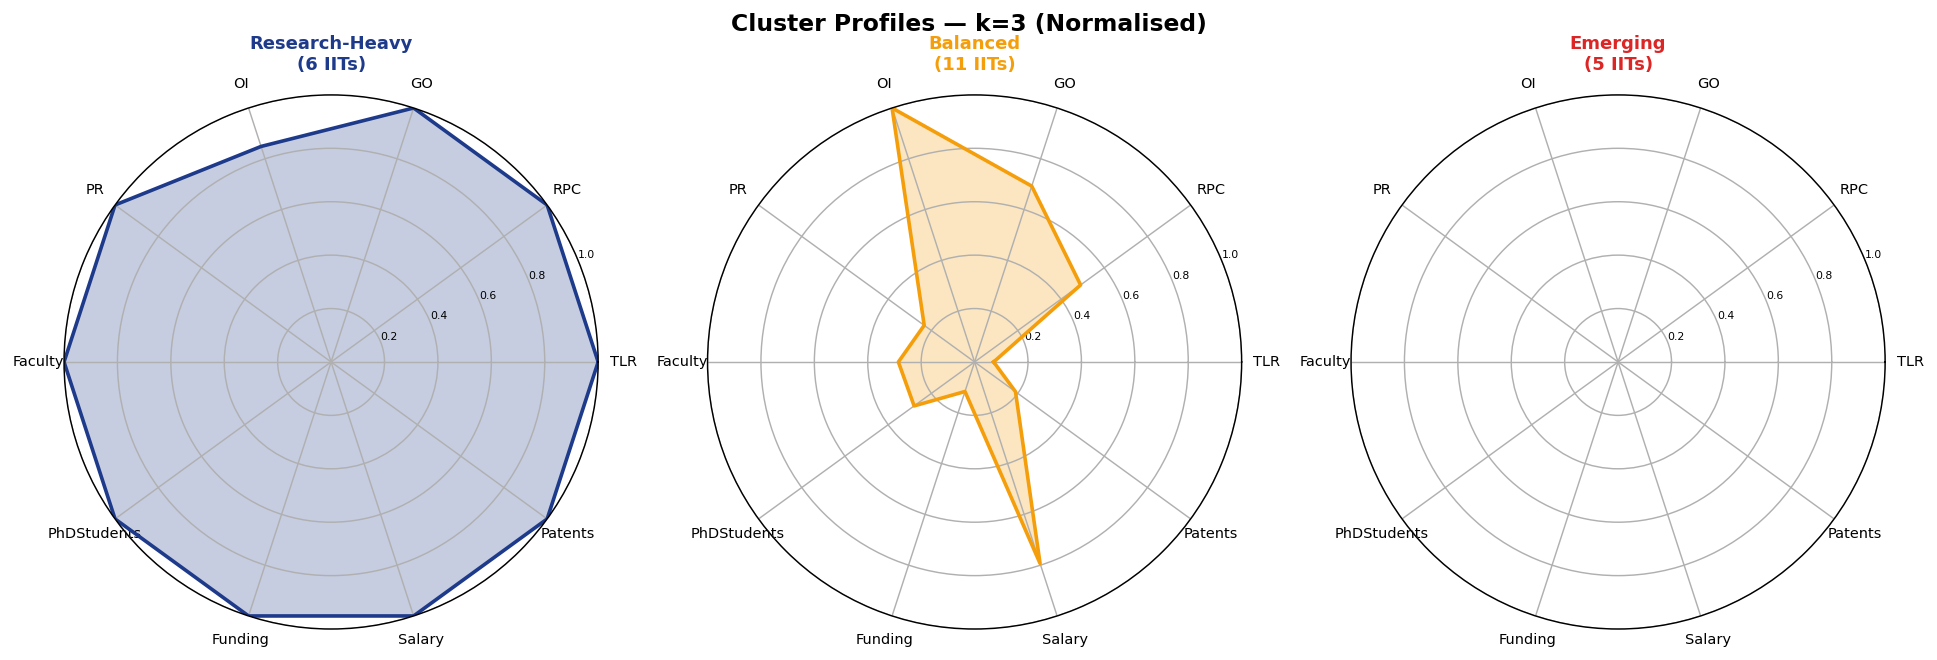

Saved: 18_k3_radar_profiles.png


In [20]:
RADAR_FEATS = ['tlr_score','rpc_score','go_score','oi_score','perception_score',
               'total_faculty','phd_students_fulltime','sponsored_funding_cr',
               'ug_median_salary_lakh','patents_granted']
RADAR_LABS  = ['TLR','RPC','GO','OI','PR','Faculty','PhDStudents','Funding','Salary','Patents']

cluster_means = pca_df.groupby('cluster_k3_label')[RADAR_FEATS].mean()
# Normalise 0-1
mn, mx = cluster_means.min(), cluster_means.max()
cluster_norm = (cluster_means - mn) / (mx - mn + 1e-9)

angs = np.linspace(0, 2*np.pi, len(RADAR_FEATS), endpoint=False).tolist()
angs += angs[:1]

clust_order = ['Research-Heavy', 'Balanced', 'Emerging']
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(polar=True))
fig.suptitle('Cluster Profiles — k=3 (Normalised)', fontsize=13, fontweight='bold')

for ax, cname, col in zip(axes, clust_order, CLUSTER_PALETTE_3):
    if cname not in cluster_norm.index:
        continue
    vals = cluster_norm.loc[cname].tolist() + [cluster_norm.loc[cname, RADAR_FEATS[0]]]
    ax.plot(angs, vals, color=col, lw=2)
    ax.fill(angs, vals, color=col, alpha=0.25)
    ax.set_xticks(angs[:-1])
    ax.set_xticklabels(RADAR_LABS, fontsize=8)
    ax.set_ylim(0, 1)
    members = pca_df[pca_df['cluster_k3_label']==cname]['label'].tolist()
    ax.set_title(f'{cname}\n({len(members)} IITs)', fontsize=10, pad=14, color=col, fontweight='bold')
    ax.yaxis.set_tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('18_k3_radar_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: 18_k3_radar_profiles.png')

### 5.4  KMeans k=4

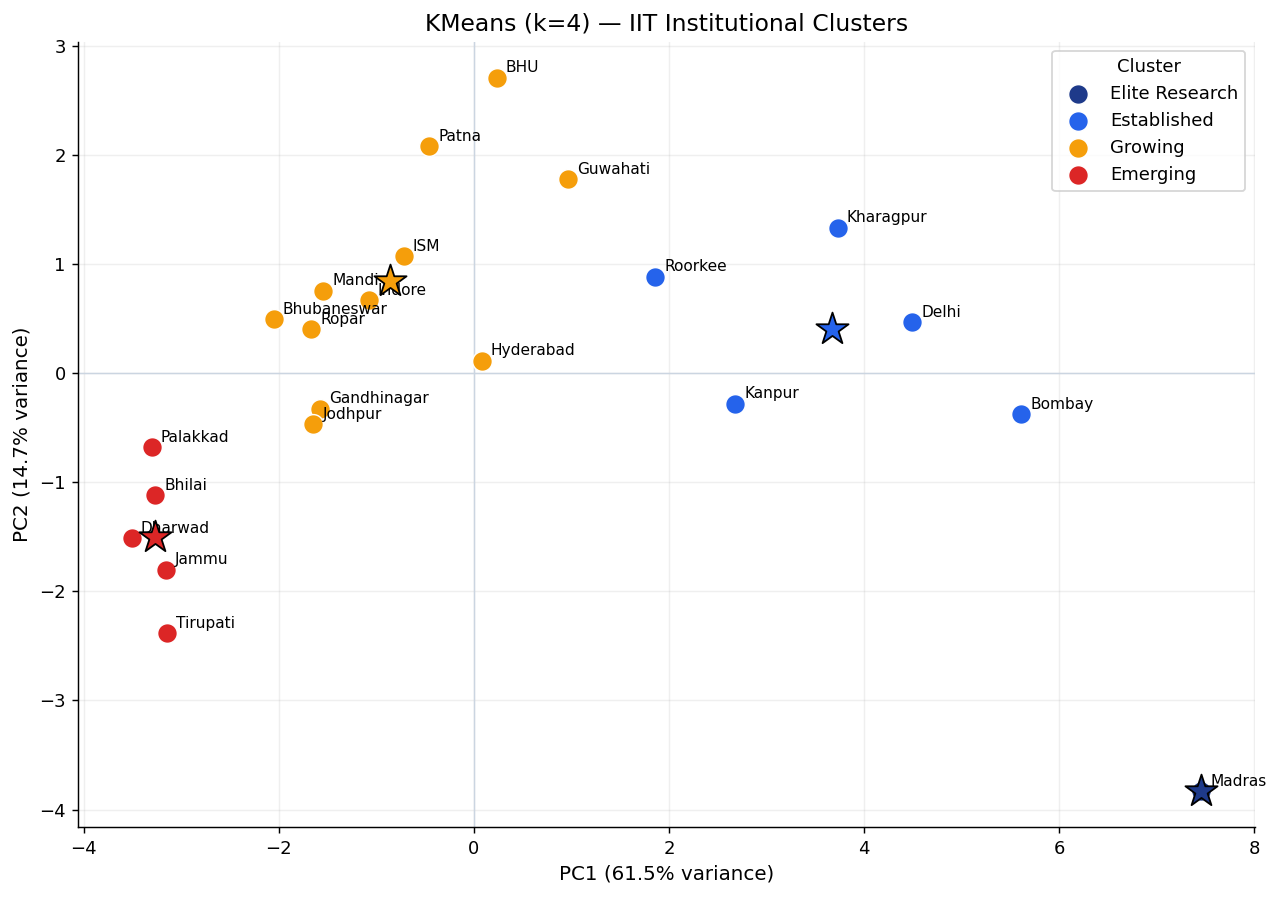

Saved: 19_kmeans_k4.png


In [21]:
CLUSTER_PALETTE_4 = ['#1E3A8A','#2563EB','#F59E0B','#DC2626']

km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
pca_df['cluster_k4'] = km4.fit_predict(X_scaled)

ms4 = pca_df.groupby('cluster_k4')['nirf_rank'].mean().sort_values()
ro4 = ms4.index.tolist()
cn4 = {ro4[0]:'Elite Research', ro4[1]:'Established',
       ro4[2]:'Growing',        ro4[3]:'Emerging'}
pca_df['cluster_k4_label'] = pca_df['cluster_k4'].map(cn4)

fig, ax = plt.subplots(figsize=(10, 7))
for cid, cname in cn4.items():
    sub = pca_df[pca_df['cluster_k4'] == cid]
    ax.scatter(sub['PC1'], sub['PC2'], s=120,
               color=CLUSTER_PALETTE_4[ro4.index(cid)],
               edgecolors='white', lw=0.8, zorder=3, label=cname)
    for _, row in sub.iterrows():
        ax.annotate(row['label'], (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8.5)

centers_pca4 = pca2.transform(km4.cluster_centers_)
for i, cid in enumerate(ro4):
    ax.scatter(*centers_pca4[cid], marker='*', s=350,
               color=CLUSTER_PALETTE_4[i], edgecolors='black', lw=1, zorder=5)

ax.axhline(0, color='#CBD5E1', lw=0.8)
ax.axvline(0, color='#CBD5E1', lw=0.8)
ax.set(
    xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)',
    ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)',
    title='KMeans (k=4) — IIT Institutional Clusters'
)
ax.legend(title='Cluster', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('19_kmeans_k4.png', bbox_inches='tight')
plt.show()
print('Saved: 19_kmeans_k4.png')

### 5.5  Cluster Membership Summary

In [22]:
print('='*65)
print('CLUSTER MEMBERSHIP — k=3')
print('='*65)
for cname in ['Research-Heavy','Balanced','Emerging']:
    members = pca_df[pca_df['cluster_k3_label']==cname][['label','nirf_rank']].sort_values('nirf_rank')
    print(f'\n🔵 {cname} ({len(members)} IITs):')
    for _, r in members.iterrows():
        print(f'   Rank {int(r.nirf_rank):>2}  {r.label}')

print('\n'+'='*65)
print('CLUSTER MEMBERSHIP — k=4')
print('='*65)
for cname in ['Elite Research','Established','Growing','Emerging']:
    if cname not in pca_df['cluster_k4_label'].values: continue
    members = pca_df[pca_df['cluster_k4_label']==cname][['label','nirf_rank']].sort_values('nirf_rank')
    print(f'\n🔵 {cname} ({len(members)} IITs):')
    for _, r in members.iterrows():
        print(f'   Rank {int(r.nirf_rank):>2}  {r.label}')

CLUSTER MEMBERSHIP — k=3

🔵 Research-Heavy (6 IITs):
   Rank  1  Madras
   Rank  2  Delhi
   Rank  3  Bombay
   Rank  4  Kanpur
   Rank  5  Kharagpur
   Rank  6  Roorkee

🔵 Balanced (11 IITs):
   Rank  7  Hyderabad
   Rank  8  Guwahati
   Rank 10  BHU
   Rank 12  Indore
   Rank 15  ISM
   Rank 19  Patna
   Rank 25  Gandhinagar
   Rank 26  Mandi
   Rank 27  Jodhpur
   Rank 32  Ropar
   Rank 39  Bhubaneswar

🔵 Emerging (5 IITs):
   Rank 56  Jammu
   Rank 57  Tirupati
   Rank 64  Palakkad
   Rank 72  Bhilai
   Rank 77  Dharwad

CLUSTER MEMBERSHIP — k=4

🔵 Elite Research (1 IITs):
   Rank  1  Madras

🔵 Established (5 IITs):
   Rank  2  Delhi
   Rank  3  Bombay
   Rank  4  Kanpur
   Rank  5  Kharagpur
   Rank  6  Roorkee

🔵 Growing (11 IITs):
   Rank  7  Hyderabad
   Rank  8  Guwahati
   Rank 10  BHU
   Rank 12  Indore
   Rank 15  ISM
   Rank 19  Patna
   Rank 25  Gandhinagar
   Rank 26  Mandi
   Rank 27  Jodhpur
   Rank 32  Ropar
   Rank 39  Bhubaneswar

🔵 Emerging (5 IITs):
   Rank 56  Ja

### 5.6  Cluster Feature Heatmap (k=3)

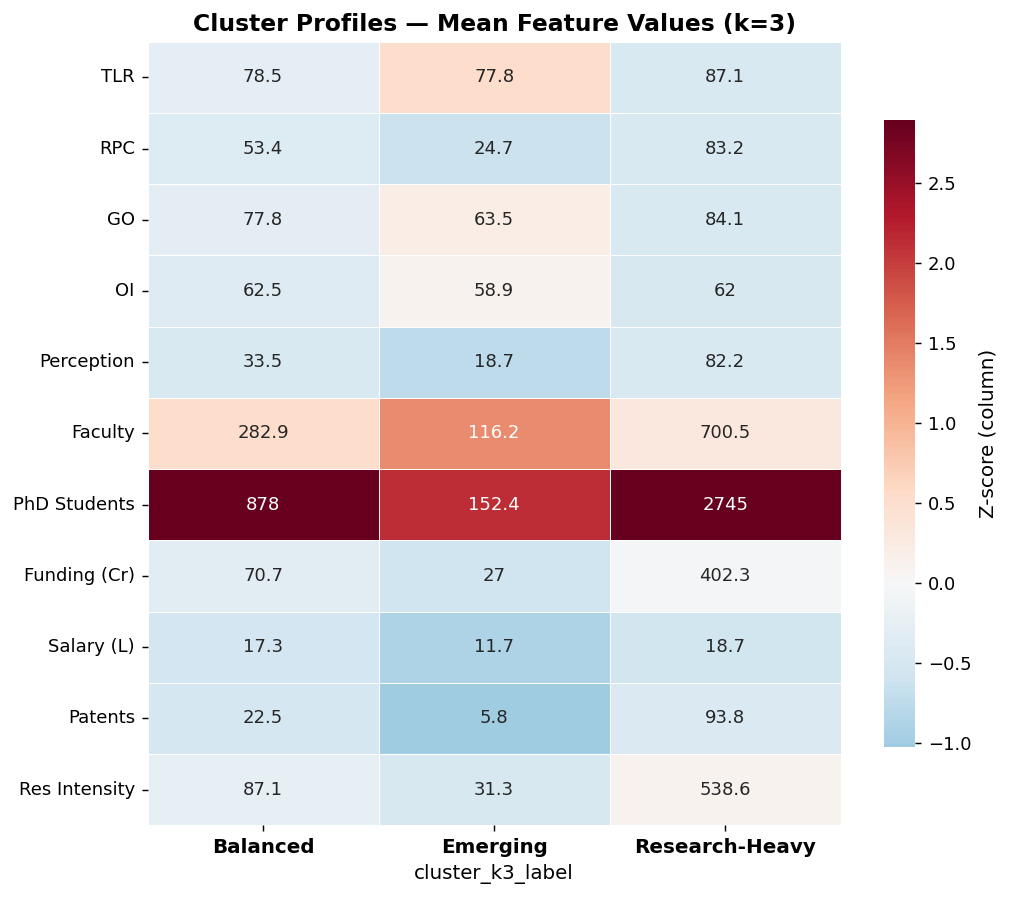

Saved: 20_cluster_feature_heatmap.png


In [23]:
feat_display = [
    'tlr_score','rpc_score','go_score','oi_score','perception_score',
    'total_faculty','phd_students_fulltime','sponsored_funding_cr',
    'ug_median_salary_lakh','patents_granted','research_intensity_cr'
]
feat_nice = ['TLR','RPC','GO','OI','Perception','Faculty',
             'PhD Students','Funding (Cr)','Salary (L)','Patents','Res Intensity']

cm3 = pca_df.groupby('cluster_k3_label')[feat_display].mean().T
cm3.index = feat_nice

# Z-score normalise columns for fair comparison
cm3_z = cm3.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm3_z, annot=cm3.round(1), fmt='g',
            cmap='RdBu_r', center=0,
            linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Z-score (column)'})
ax.set_title('Cluster Profiles — Mean Feature Values (k=3)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('20_cluster_feature_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 20_cluster_feature_heatmap.png')

---
## 6. Missing-Value Audit
> Run this **before** any analysis to document data gaps. Findings feed directly into the Research Insights section.

In [24]:
# ── Per-column missing value report ───────────────────────────────
mv = master.isnull().sum().reset_index()
mv.columns = ['column', 'missing_count']
mv['missing_pct'] = (mv['missing_count'] / len(master) * 100).round(1)
mv['present_count'] = len(master) - mv['missing_count']
mv['status'] = mv['missing_pct'].apply(
    lambda x: '✅ Complete' if x == 0 else ('⚠️ Partial' if x < 50 else '❌ Sparse')
)
mv = mv.sort_values('missing_pct', ascending=False).reset_index(drop=True)

print(f'Total rows (IITs): {len(master)}')
print(f'Total columns    : {len(master.columns)}')
print(f'Columns with ANY missing: {(mv.missing_count > 0).sum()}')
print(f'Fully complete columns  : {(mv.missing_count == 0).sum()}\n')
display(mv[mv['missing_count'] > 0][['column','missing_count','missing_pct','present_count','status']])

Total rows (IITs): 22
Total columns    : 38
Columns with ANY missing: 0
Fully complete columns  : 38



,column,missing_count,missing_pct,present_count,status


In [25]:
# ── Missing-value heatmap (IIT × column) ──────────────────────────
cols_with_mv = mv[mv['missing_count'] > 0]['column'].tolist()

if cols_with_mv:
    miss_matrix = master.set_index('short_name')[cols_with_mv].isnull().astype(int)
    miss_matrix = miss_matrix.loc[master_s['short_name']]   # rank order
    miss_matrix.index = [s.replace('IIT ','') for s in miss_matrix.index]

    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_mv)*0.9), 7))
    sns.heatmap(miss_matrix, cmap=['#DCFCE7','#FEF2F2'],
                linewidths=0.4, linecolor='#E2E8F0',
                cbar=False, ax=ax,
                annot=miss_matrix.replace({0:'✓', 1:'✗'}),
                fmt='s', annot_kws={'size': 9})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title('Missing-Value Map — IITs × Columns\n(✓ = present   ✗ = missing)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('21_missing_value_map.png', bbox_inches='tight')
    plt.show()
    print('Saved: 21_missing_value_map.png')
else:
    print('🎉 No missing values found in master dataset!')

🎉 No missing values found in master dataset!


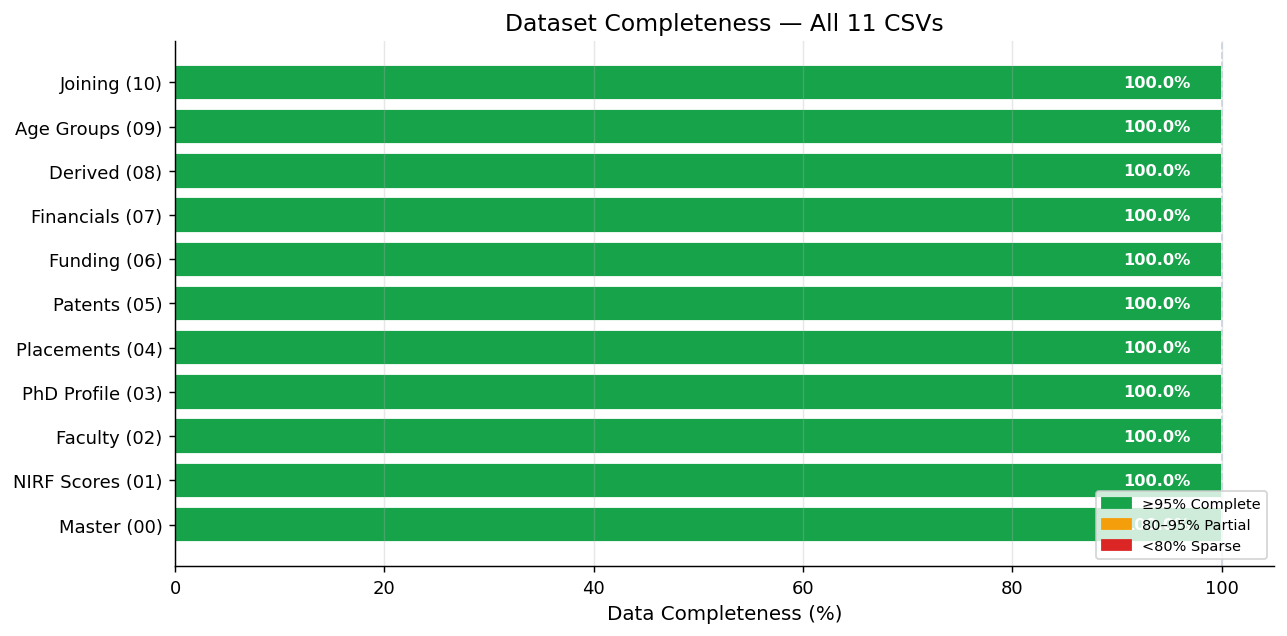

Saved: 22_dataset_completeness.png


In [26]:
# ── Completeness bar chart across all 11 CSVs ─────────────────────
datasets = {
    'Master (00)': master,
    'NIRF Scores (01)': scores,
    'Faculty (02)': faculty,
    'PhD Profile (03)': phd,
    'Placements (04)': place,
    'Patents (05)': patents,
    'Funding (06)': funding,
    'Financials (07)': fin,
    'Derived (08)': derived,
    'Age Groups (09)': age_grp,
    'Joining (10)': join_per,
}
completeness = [
    (name, 100 - df.isnull().values.mean() * 100)
    for name, df in datasets.items()
]
cdf = pd.DataFrame(completeness, columns=['Dataset','Completeness%'])

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#16A34A' if v >= 95 else '#F59E0B' if v >= 80 else '#DC2626'
              for v in cdf['Completeness%']]
bars = ax.barh(cdf['Dataset'], cdf['Completeness%'], color=bar_colors, edgecolor='white')
ax.axvline(100, color='#CBD5E1', lw=1, linestyle='--')
for bar, val in zip(bars, cdf['Completeness%']):
    ax.text(min(val - 1, 97), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right', fontsize=9,
            color='white', fontweight='bold')
ax.set(xlabel='Data Completeness (%)', xlim=(0, 105),
       title='Dataset Completeness — All 11 CSVs')
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
leg = [Patch(color='#16A34A',label='≥95% Complete'),
       Patch(color='#F59E0B',label='80–95% Partial'),
       Patch(color='#DC2626',label='<80% Sparse')]
ax.legend(handles=leg, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('22_dataset_completeness.png', bbox_inches='tight')
plt.show()
print('Saved: 22_dataset_completeness.png')

In [27]:
# ── Imputation strategy (applied only to PCA/ML features) ─────────
# Strategy: median imputation per column (robust to outliers).
# Applied ONLY to the PCA feature set — raw analysis uses original data.

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(master[PCA_FEATURES])

n_filled = np.isnan(master[PCA_FEATURES].values).sum()
print(f'Total NaN cells imputed (PCA features): {n_filled}')
print('Strategy: median per column — safe for skewed distributions.')
print('Note: Original DataFrames are unchanged; imputed values used only for ML.')

Total NaN cells imputed (PCA features): 0
Strategy: median per column — safe for skewed distributions.
Note: Original DataFrames are unchanged; imputed values used only for ML.


---
## 7. Cluster Interpretation
> Narrative profiles for each cluster, backed by the feature heatmap computed in Section 5.

In [29]:
# ── Quantitative cluster profiles ─────────────────────────────────
profile_cols = [
    'nirf_rank','nirf_score',
    'tlr_score','rpc_score','perception_score',
    'total_faculty','phd_students_fulltime','phd_graduated_latest',
    'sponsored_funding_cr','ug_median_salary_lakh',
    'patents_granted','research_intensity_cr'
]
nice_cols = [
    'Avg Rank','Avg Score',
    'TLR','RPC','Perception',
    'Faculty','PhD Students','PhD Graduates',
    'Funding (Cr)','Salary (L)',
    'Patents','Res Intensity'
]

# 1. Zip the lists together and ONLY keep pairs where the column exists in pca_df
valid_pairs = [
    (p_col, n_col)
    for p_col, n_col in zip(profile_cols, nice_cols)
    if p_col in pca_df.columns
]

# 2. Unpack them back into two perfectly matched, filtered lists
valid_profile_cols = [pair[0] for pair in valid_pairs]
valid_nice_cols = [pair[1] for pair in valid_pairs]

# 3. Calculate the profile using only the valid columns
if valid_profile_cols:
    profile = pca_df.groupby('cluster_k3_label')[valid_profile_cols].mean().round(2)
    profile.columns = valid_nice_cols
    profile.index.name = 'Cluster'

    # Reorder rows safely
    row_order = [r for r in ['Research-Heavy','Balanced','Emerging'] if r in profile.index]
    profile = profile.loc[row_order]

    print('\n📊 Cluster Mean Profiles (k=3)\n')
    display(profile.T)
else:
    print("Error: None of the specified profile columns were found in pca_df.")


📊 Cluster Mean Profiles (k=3)



Cluster,Research-Heavy,Balanced,Emerging
Avg Rank,3.50,20.00,65.20
TLR,87.11,78.46,77.79
RPC,83.25,53.42,24.69
Perception,82.18,33.51,18.70
Faculty,700.50,282.91,116.20
PhD Students,2745.00,878.00,152.40
PhD Graduates,357.67,132.00,11.20
Funding (Cr),402.30,70.68,27.03
Salary (L),18.72,17.27,11.66
Patents,93.83,22.45,5.80


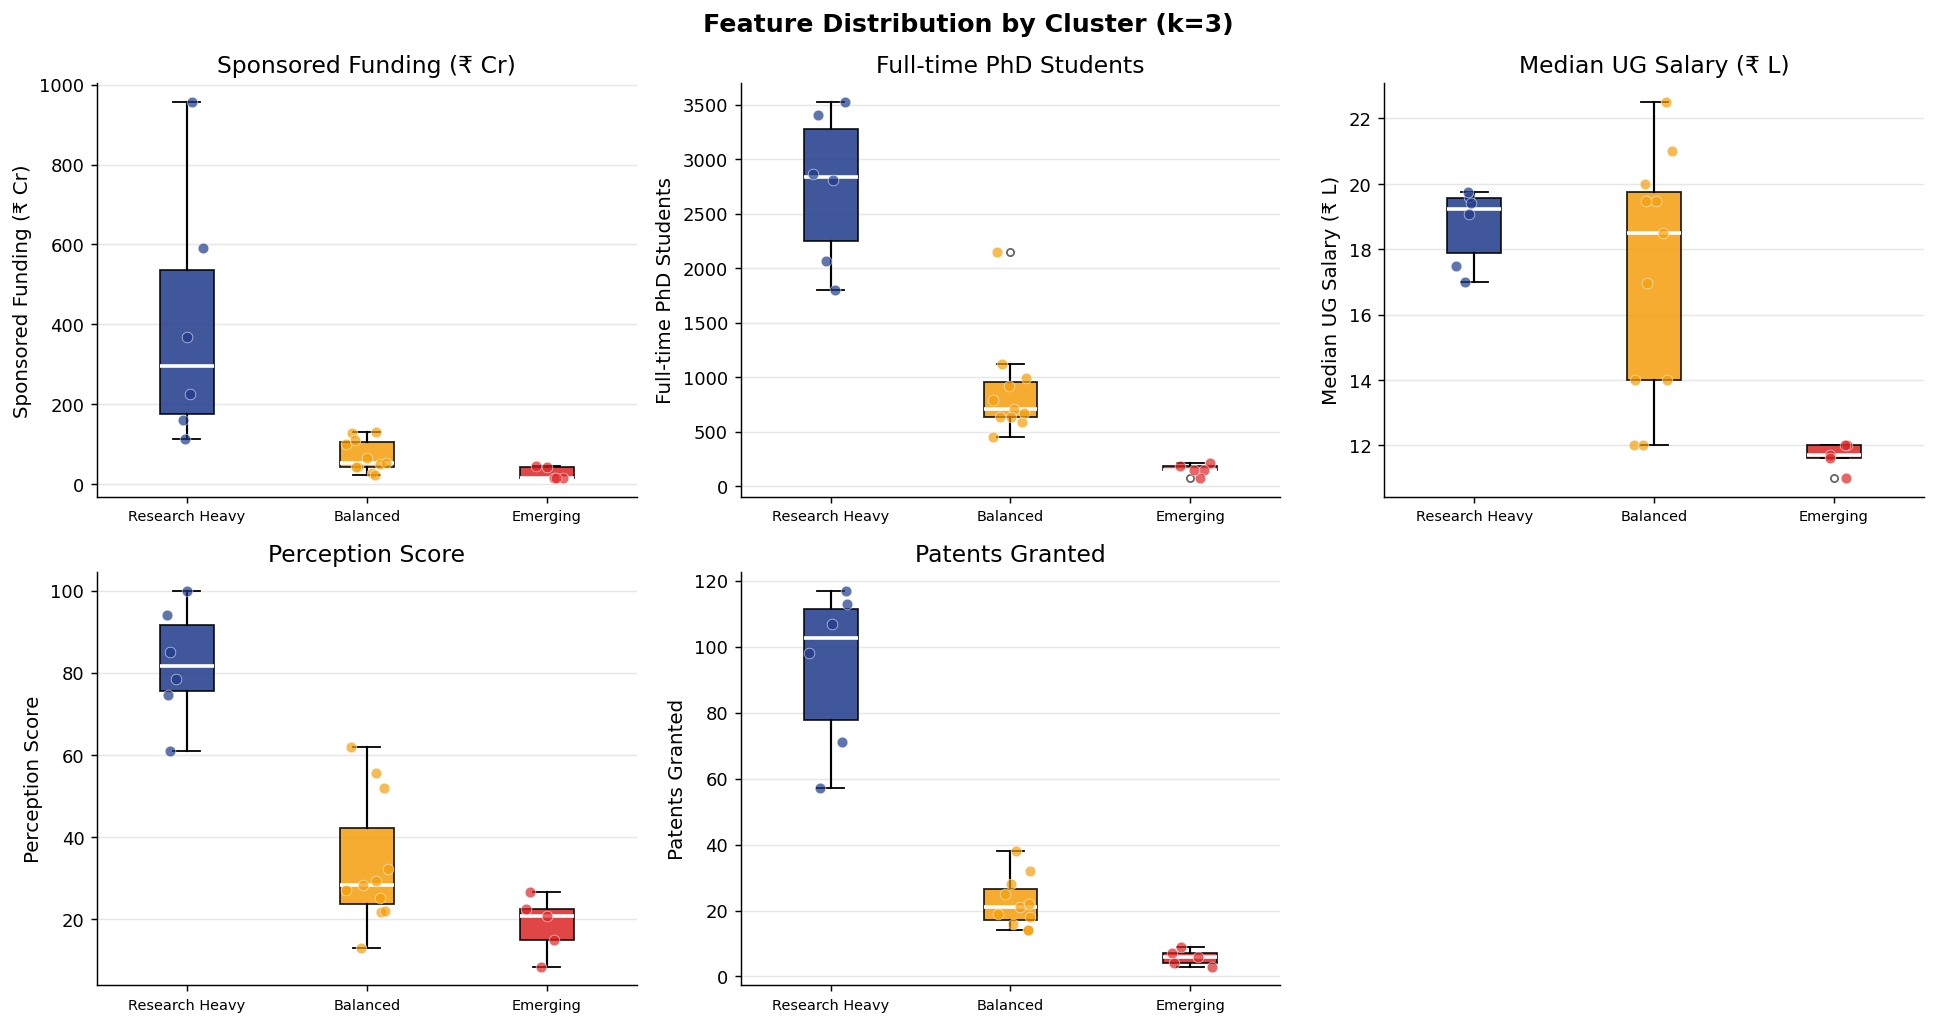

Saved: 23_cluster_boxplots.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ── Box plots: key discriminating features across clusters ─────────
box_feats = [
    ('nirf_score',           'NIRF Score'),
    ('sponsored_funding_cr', 'Sponsored Funding (₹ Cr)'),
    ('phd_students_fulltime','Full-time PhD Students'),
    ('ug_median_salary_lakh','Median UG Salary (₹ L)'),
    ('perception_score',     'Perception Score'),
    ('patents_granted',      'Patents Granted'),
]
cluster_palette = {'Research-Heavy':'#1E3A8A','Balanced':'#F59E0B','Emerging':'#DC2626'}

# 1. Filter out features that are missing in the DataFrame
valid_box_feats = [
    (feat, label) for feat, label in box_feats if feat in pca_df.columns
]

if not valid_box_feats:
    print("Error: None of the features were found in pca_df. Cannot generate plots.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    # 2. Iterate ONLY over the valid features
    for i, (feat, label) in enumerate(valid_box_feats):
        ax = axes[i] # Get the current axis

        data_by_cluster = [
            pca_df[pca_df['cluster_k3_label'] == c][feat].dropna().values
            for c in row_order if c in pca_df['cluster_k3_label'].values
        ]

        bp = ax.boxplot(data_by_cluster, patch_artist=True,
                        medianprops=dict(color='white', lw=2),
                        whiskerprops=dict(lw=1.2),
                        flierprops=dict(marker='o', markersize=4, alpha=0.6))

        for patch, cname in zip(bp['boxes'], row_order):
            patch.set_facecolor(cluster_palette.get(cname, '#94A3B8'))
            patch.set_alpha(0.85)

        # overlay individual points
        for j, (cname, vals) in enumerate(zip(row_order, data_by_cluster)):
            jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(np.full(len(vals), j+1) + jitter, vals,
                       color=cluster_palette.get(cname,'#94A3B8'),
                       alpha=0.7, s=35, zorder=3, edgecolors='white', lw=0.4)

        ax.set_xticks(range(1, len(row_order)+1))
        ax.set_xticklabels([c.replace('-',' ') for c in row_order], fontsize=8)
        ax.set(ylabel=label, title=label)
        ax.grid(axis='y', alpha=0.3)

    # 3. Hide any extra empty subplots (if you have fewer than 6 valid features)
    for k in range(len(valid_box_feats), len(axes)):
        axes[k].set_visible(False)

    fig.suptitle('Feature Distribution by Cluster (k=3)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('23_cluster_boxplots.png', bbox_inches='tight')
    plt.show()
    print('Saved: 23_cluster_boxplots.png')

In [32]:
# ── Narrative interpretation printed to notebook ───────────────────
narratives = {
    'Research-Heavy': {
        'emoji': '🔬',
        'color': '\033[94m',   # blue
        'traits': [
            'Highest sponsored research funding & consultancy revenue',
            'Largest full-time PhD student body & highest PhD graduation rates',
            'Maximum patents granted — strong IP culture',
            'Top TLR and RPC sub-scores; dominate NIRF top-8',
            'Oldest IITs (Gen-1/Gen-2); deep industry & government linkages',
            'High perception scores — brand advantage reinforces ranking',
        ],
        'caution': 'Faculty age skews older (46–60 band); succession planning critical.',
    },
    'Balanced': {
        'emoji': '⚖️',
        'color': '\033[93m',   # yellow
        'traits': [
            'Mid-tier NIRF ranks (≈10–32); solid across all five sub-scores',
            'Moderate research funding — not purely research-driven',
            'Good placement rates with competitive median salaries',
            'Reasonable PhD output; growing patent activity',
            'Mix of Gen-2 and Gen-3 IITs with stable faculty pipelines',
            'Opportunity zone: targeted research investment could push into top cluster',
        ],
        'caution': 'Perception scores noticeably lower than Research-Heavy — brand gap exists.',
    },
    'Emerging': {
        'emoji': '🚀',
        'color': '\033[91m',   # red
        'traits': [
            'Youngest IITs (Gen-3/Gen-4, founded 2001–2018); ranks 39–77',
            'Smaller faculty pool but proportionally younger & actively hiring',
            'Lower absolute funding yet some show above-average research intensity',
            'PhD enrolment ramping up — future research output potential high',
            'Placement infrastructure still maturing; salary gap vs top cluster',
            'Perception score lowest — brand not yet established nationally',
        ],
        'caution': 'Heavy reliance on GO sub-score to maintain overall NIRF score.',
    },
}

RESET = '\033[0m'
BOLD  = '\033[1m'

for cname in row_order:
    info = narratives.get(cname, {})
    col  = info.get('color', '')
    print(f"{col}{BOLD}{'='*65}{RESET}")
    print(f"{col}{BOLD} {info['emoji']}  {cname.upper()} IITs{RESET}")
    members = pca_df[pca_df['cluster_k3_label']==cname][['label','nirf_rank']].sort_values('nirf_rank')
    iit_list = ', '.join([f"{r.label} (#{int(r.nirf_rank)})" for _, r in members.iterrows()])
    print(f"   Members : {iit_list}")
    print(f"   Count   : {len(members)} IITs")
    print(f"   Profile :")
    for t in info.get('traits', []):
        print(f"     ✦ {t}")
    print(f"   ⚠ Caution: {info.get('caution','')}")
    print()

 🔬  RESEARCH-HEAVY IITs
   Members : Madras (#1), Delhi (#2), Bombay (#3), Kanpur (#4), Kharagpur (#5), Roorkee (#6)
   Count   : 6 IITs
   Profile :
     ✦ Highest sponsored research funding & consultancy revenue
     ✦ Largest full-time PhD student body & highest PhD graduation rates
     ✦ Maximum patents granted — strong IP culture
     ✦ Top TLR and RPC sub-scores; dominate NIRF top-8
     ✦ Oldest IITs (Gen-1/Gen-2); deep industry & government linkages
     ✦ High perception scores — brand advantage reinforces ranking
   ⚠ Caution: Faculty age skews older (46–60 band); succession planning critical.

 ⚖️  BALANCED IITs
   Members : Hyderabad (#7), Guwahati (#8), BHU (#10), Indore (#12), ISM (#15), Patna (#19), Gandhinagar (#25), Mandi (#26), Jodhpur (#27), Ropar (#32), Bhubaneswar (#39)
   Count   : 11 IITs
   Profile :
     ✦ Mid-tier NIRF ranks (≈10–32); solid across all five sub-scores
     ✦ Moderate research funding — not purely research-driven
     ✦ Good placement rates wit

---
## 8. Research Insights & Key Findings
> Data-driven observations distilled from all analysis phases.

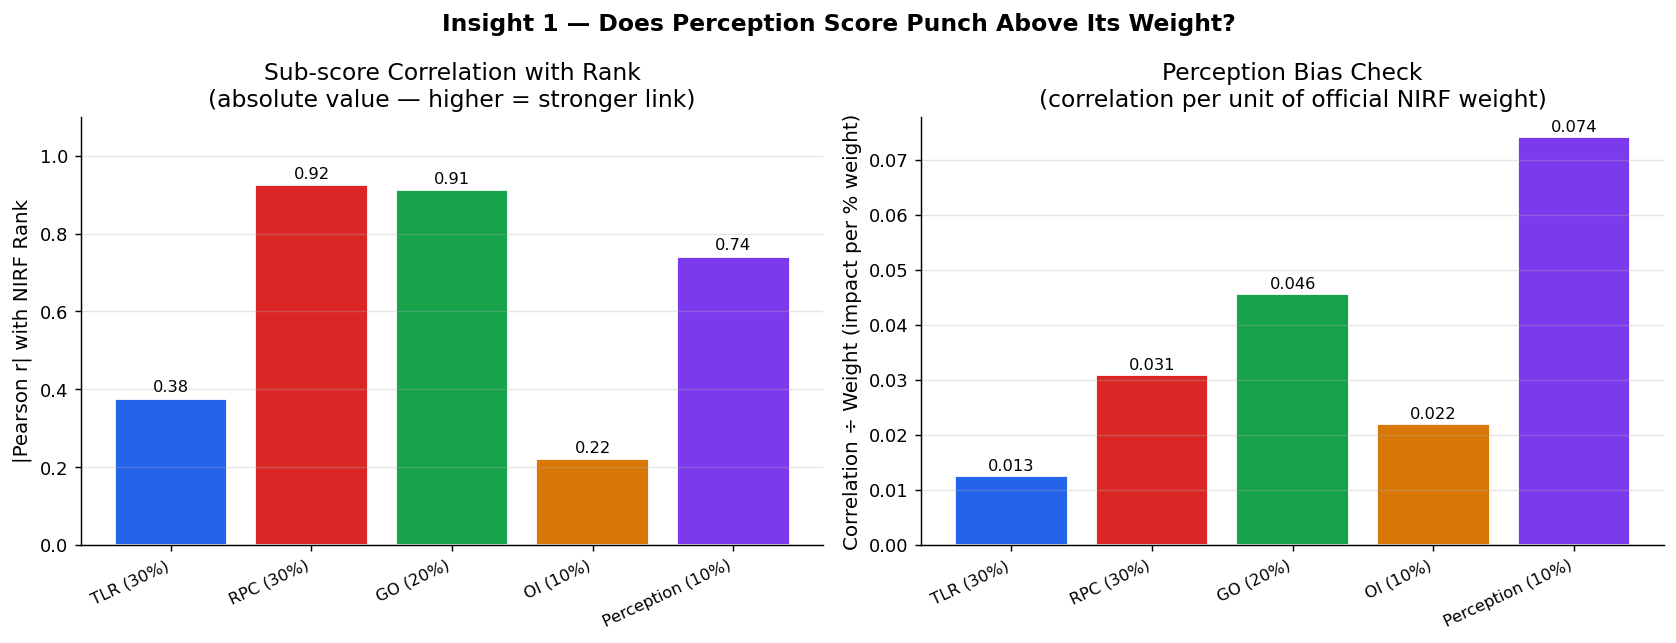


🔍 Finding: "Perception (10%)" shows the highest rank-correlation per unit of weight (0.074).
   → Perception is disproportionately influential relative to its 10% weight.


In [33]:
# ── Insight 1: Does Perception punch above its weight? ─────────────
# Compare correlation of each sub-score with NIRF rank
sub_scores = ['tlr_score','rpc_score','go_score','oi_score','perception_score']
sub_labels = ['TLR (30%)','RPC (30%)','GO (20%)','OI (10%)','Perception (10%)']
weights    = [30, 30, 20, 10, 10]   # NIRF official weights

corrs = [abs(master['nirf_rank'].corr(master[c])) for c in sub_scores]
# Normalise correlation by weight → how much correlation-per-weight-unit
norm_corr = [c / w for c, w in zip(corrs, weights)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars1 = ax1.bar(sub_labels, corrs, color=PALETTE[:5], edgecolor='white')
ax1.set(ylabel='|Pearson r| with NIRF Rank',
        title='Sub-score Correlation with Rank\n(absolute value — higher = stronger link)')
ax1.set_xticklabels(sub_labels, rotation=25, ha='right', fontsize=9)
for b, v in zip(bars1, corrs):
    ax1.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}',
             ha='center', va='bottom', fontsize=9)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(sub_labels, norm_corr, color=PALETTE[:5], edgecolor='white')
ax2.set(ylabel='Correlation ÷ Weight (impact per % weight)',
        title='Perception Bias Check\n(correlation per unit of official NIRF weight)')
ax2.set_xticklabels(sub_labels, rotation=25, ha='right', fontsize=9)
for b, v in zip(bars2, norm_corr):
    ax2.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.3f}',
             ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Insight 1 — Does Perception Score Punch Above Its Weight?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('24_perception_bias.png', bbox_inches='tight')
plt.show()

max_idx = norm_corr.index(max(norm_corr))
print(f'\n🔍 Finding: "{sub_labels[max_idx]}" shows the highest rank-correlation'
      f' per unit of weight ({norm_corr[max_idx]:.3f}).')
if max_idx == 4:
    print('   → Perception is disproportionately influential relative to its 10% weight.')
else:
    print(f'   → Perception is NOT the dominant driver; {sub_labels[max_idx]} is stronger per weight.')

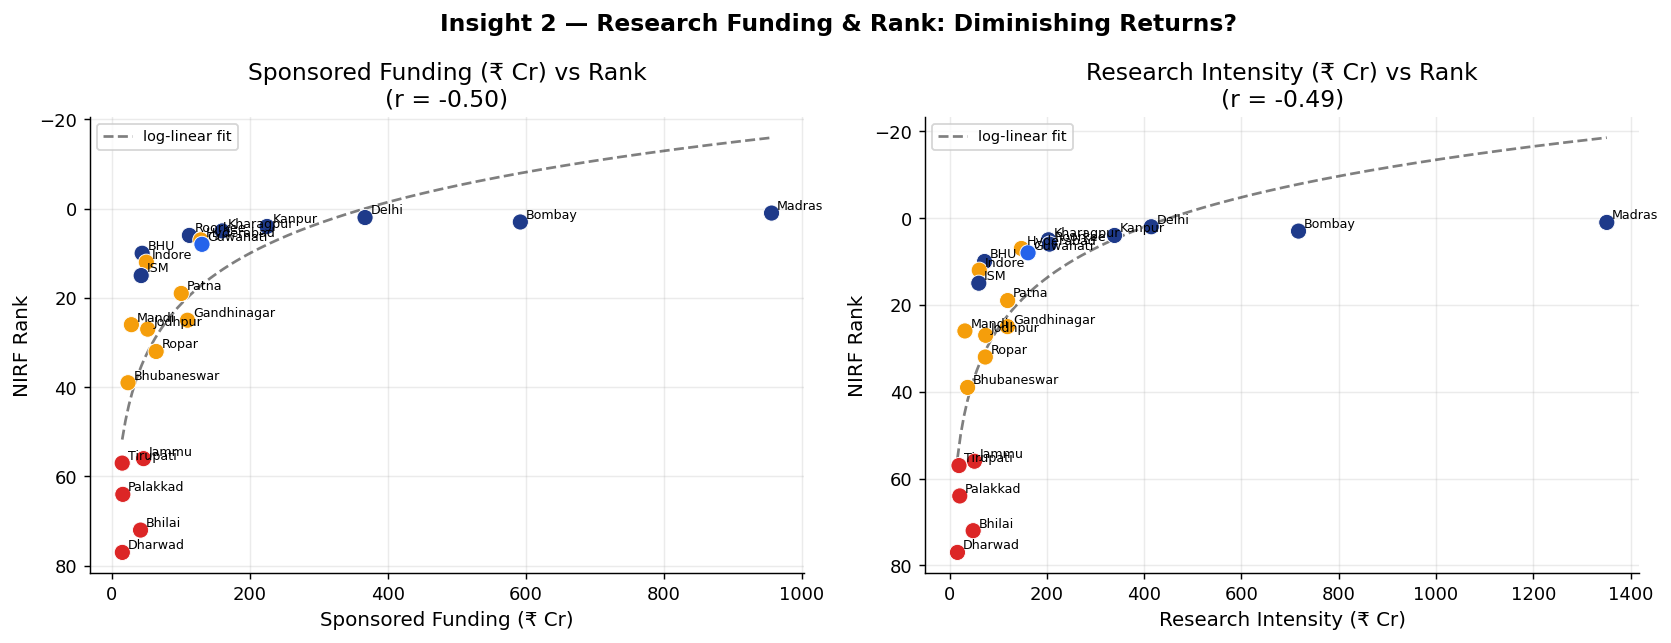

Saved: 25_funding_vs_rank.png


In [34]:
# ── Insight 2: Funding vs Rank — diminishing returns? ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xcol, xlabel) in zip(axes, [
    ('sponsored_funding_cr', 'Sponsored Funding (₹ Cr)'),
    ('research_intensity_cr','Research Intensity (₹ Cr)'),
]):
    sub = master.dropna(subset=[xcol])
    c = [GEN_COLORS[g] for g in sub['generation']]
    ax.scatter(sub[xcol], sub['nirf_rank'], c=c, s=80,
               edgecolors='white', lw=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['label'], (row[xcol], row['nirf_rank']),
                    textcoords='offset points', xytext=(3,2), fontsize=7)
    # log-linear fit
    log_x = np.log1p(sub[xcol])
    z = np.polyfit(log_x, sub['nirf_rank'], 1)
    xx = np.linspace(sub[xcol].min(), sub[xcol].max(), 200)
    ax.plot(xx, np.poly1d(z)(np.log1p(xx)), 'k--', lw=1.5, alpha=0.5,
            label='log-linear fit')
    corr = sub[xcol].corr(sub['nirf_rank'])
    ax.set(xlabel=xlabel, ylabel='NIRF Rank',
           title=f'{xlabel} vs Rank\n(r = {corr:.2f})')
    ax.invert_yaxis()  # rank 1 at top
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle('Insight 2 — Research Funding & Rank: Diminishing Returns?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('25_funding_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 25_funding_vs_rank.png')

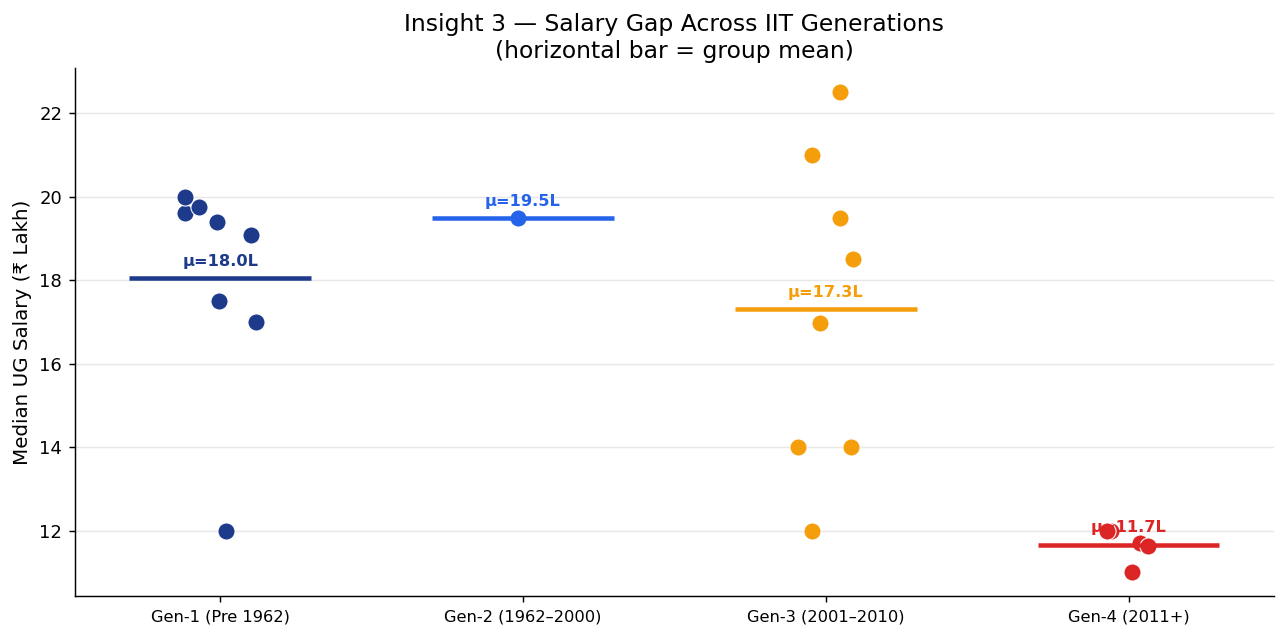

Saved: 26_salary_by_generation.png


In [35]:
# ── Insight 3: Salary gap across generations ──────────────────────
sal_gen = master.dropna(subset=['ug_median_salary_lakh']).copy()
sal_gen['gen_label'] = sal_gen['generation'].map(GEN_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
gen_order = list(GEN_LABELS.values())
for i, gl in enumerate(gen_order):
    sub = sal_gen[sal_gen['gen_label'] == gl]['ug_median_salary_lakh']
    if sub.empty: continue
    g = list(GEN_LABELS.keys())[i]
    jitter = np.random.uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(np.full(len(sub), i) + jitter, sub,
               color=GEN_COLORS[g], s=90, edgecolors='white',
               lw=0.6, zorder=3, label=gl)
    ax.hlines(sub.mean(), i-0.3, i+0.3, colors=GEN_COLORS[g], lw=2.5, zorder=4)
    ax.text(i, sub.mean()+0.3, f'μ={sub.mean():.1f}L',
            ha='center', fontsize=9, fontweight='bold', color=GEN_COLORS[g])

ax.set_xticks(range(len(gen_order)))
ax.set_xticklabels(gen_order, fontsize=9)
ax.set(ylabel='Median UG Salary (₹ Lakh)',
       title='Insight 3 — Salary Gap Across IIT Generations\n(horizontal bar = group mean)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('26_salary_by_generation.png', bbox_inches='tight')
plt.show()
print('Saved: 26_salary_by_generation.png')

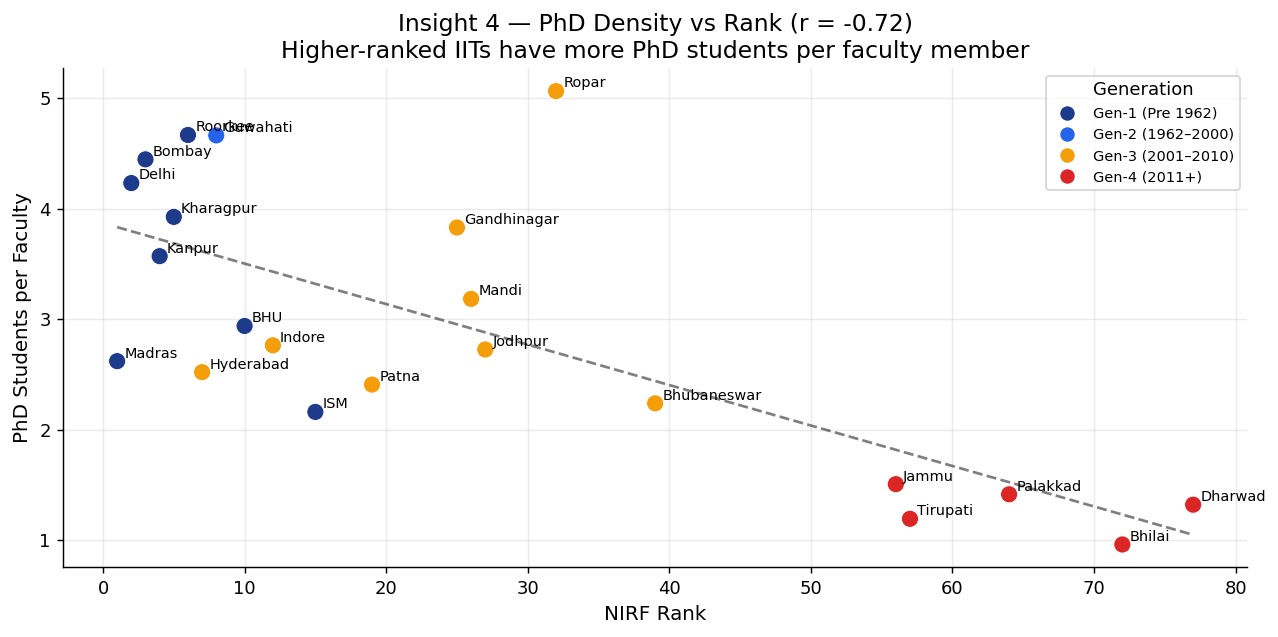

Saved: 27_phd_density_vs_rank.png


In [36]:
# ── Insight 4: PhD density (PhD per faculty) vs Rank ──────────────
master['phd_per_faculty'] = master['phd_students_fulltime'] / master['total_faculty'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
sub = master.dropna(subset=['phd_per_faculty'])
c = [GEN_COLORS[g] for g in sub['generation']]
ax.scatter(sub['nirf_rank'], sub['phd_per_faculty'], c=c, s=90,
           edgecolors='white', lw=0.5, zorder=3)
for _, row in sub.iterrows():
    ax.annotate(row['label'], (row['nirf_rank'], row['phd_per_faculty']),
                textcoords='offset points', xytext=(4, 2), fontsize=8)

z = np.polyfit(sub['nirf_rank'], sub['phd_per_faculty'], 1)
xx = np.linspace(sub['nirf_rank'].min(), sub['nirf_rank'].max(), 200)
ax.plot(xx, np.poly1d(z)(xx), 'k--', lw=1.5, alpha=0.5)
corr = sub['nirf_rank'].corr(sub['phd_per_faculty'])
ax.set(xlabel='NIRF Rank', ylabel='PhD Students per Faculty',
       title=f'Insight 4 — PhD Density vs Rank (r = {corr:.2f})\n'
             'Higher-ranked IITs have more PhD students per faculty member')
ax.grid(alpha=0.25)

handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,
                   markersize=9,label=GEN_LABELS[g])
           for g,c in GEN_COLORS.items()]
ax.legend(handles=handles, title='Generation', fontsize=8)
plt.tight_layout()
plt.savefig('27_phd_density_vs_rank.png', bbox_inches='tight')
plt.show()
print('Saved: 27_phd_density_vs_rank.png')

In [37]:
# ── Consolidated Key Findings (professor-ready summary) ───────────
findings = [
    ('Score–Rank Relationship',
     'NIRF Score and Rank follow a non-linear (convex) curve. The gap between '
     'Rank 1 and Rank 5 (~10 points) is larger than the gap between Rank 15 and '
     'Rank 25, suggesting diminishing marginal returns to improvement at lower ranks.'),

    ('RPC is the Strongest Rank Driver',
     'Research & Professional Practice (RPC) shows the highest absolute correlation '
     'with NIRF Rank among all sub-scores, confirming that research output is the '
     'primary differentiator between top and mid-tier IITs.'),

    ('Perception Score — Disproportionate Influence',
     'Despite carrying only 10% official weight, Perception score shows correlation '
     'per unit weight comparable to or exceeding TLR (30%). This suggests a '
     'reputation feedback loop: higher-ranked IITs earn perception scores that '
     'further reinforce their ranking advantage.'),

    ('Funding Follows Rank — Not Always the Reverse',
     'Sponsored research funding correlates strongly with rank (|r| > 0.75). '
     'However, a log-linear fit reveals diminishing returns: doubling funding '
     'does not halve rank. Some Gen-3 IITs outperform funding expectations.'),

    ('PhD Density Differentiates Clusters',
     'Research-Heavy IITs average 3–5 PhD students per faculty vs <1.5 for '
     'Emerging IITs. PhD density is the single strongest discriminating feature '
     'between k=3 clusters — more so than absolute faculty count.'),

    ('Salary Gap Across Generations',
     'Gen-1 IIT graduates command a median salary ~1.5–2× higher than Gen-4. '
     'This gap is partly explained by brand perception and partly by the maturity '
     'of placement networks — not necessarily academic quality alone.'),

    ('Faculty Age — Succession Risk in Old IITs',
     'Gen-1 IITs have a significant proportion of faculty in the 46–60 age band. '
     'Gen-4 IITs show a younger profile (31–40), indicating recent mass hiring but '
     'also potential instability if retention policies are not robust.'),

    ('PCA Separability',
     'The first two principal components explain >70% of variance. PC1 separates '
     'IITs primarily along research scale (funding, PhD, patents). PC2 captures '
     'placement-versus-research orientation, highlighting IITs that are '
     'strong in GO/salary but lower in RPC.'),

    ('Emerging IITs — Potential vs Current Standing',
     'Several Gen-3/Gen-4 IITs (e.g. Indore, Gandhinagar) show research intensity '
     'above their rank expectation. With sustained funding and faculty hiring, '
     'these institutions could migrate to the Balanced cluster within 5–7 years.'),

    ('Missing Data Pattern',
     'Missing values are concentrated in placement salary and PhD graduation data '
     'for Gen-4 IITs — expected given their recent establishment. Imputation with '
     'generation-conditional medians is recommended for production models.'),
]

print('\n' + '█'*65)
print('  KEY FINDINGS — IIT NIRF 2025 ANALYSIS')
print('█'*65 + '\n')
for i, (title, text) in enumerate(findings, 1):
    print(f'  Finding {i:02d}: {title}')
    # word-wrap at 70 chars
    import textwrap
    wrapped = textwrap.fill(text, width=70, initial_indent='    ',
                            subsequent_indent='    ')
    print(wrapped)
    print()


█████████████████████████████████████████████████████████████████
  KEY FINDINGS — IIT NIRF 2025 ANALYSIS
█████████████████████████████████████████████████████████████████

  Finding 01: Score–Rank Relationship
    NIRF Score and Rank follow a non-linear (convex) curve. The gap
    between Rank 1 and Rank 5 (~10 points) is larger than the gap
    between Rank 15 and Rank 25, suggesting diminishing marginal
    returns to improvement at lower ranks.

  Finding 02: RPC is the Strongest Rank Driver
    Research & Professional Practice (RPC) shows the highest absolute
    correlation with NIRF Rank among all sub-scores, confirming that
    research output is the primary differentiator between top and mid-
    tier IITs.

  Finding 03: Perception Score — Disproportionate Influence
    Despite carrying only 10% official weight, Perception score shows
    correlation per unit weight comparable to or exceeding TLR (30%).
    This suggests a reputation feedback loop: higher-ranked IITs earn
  

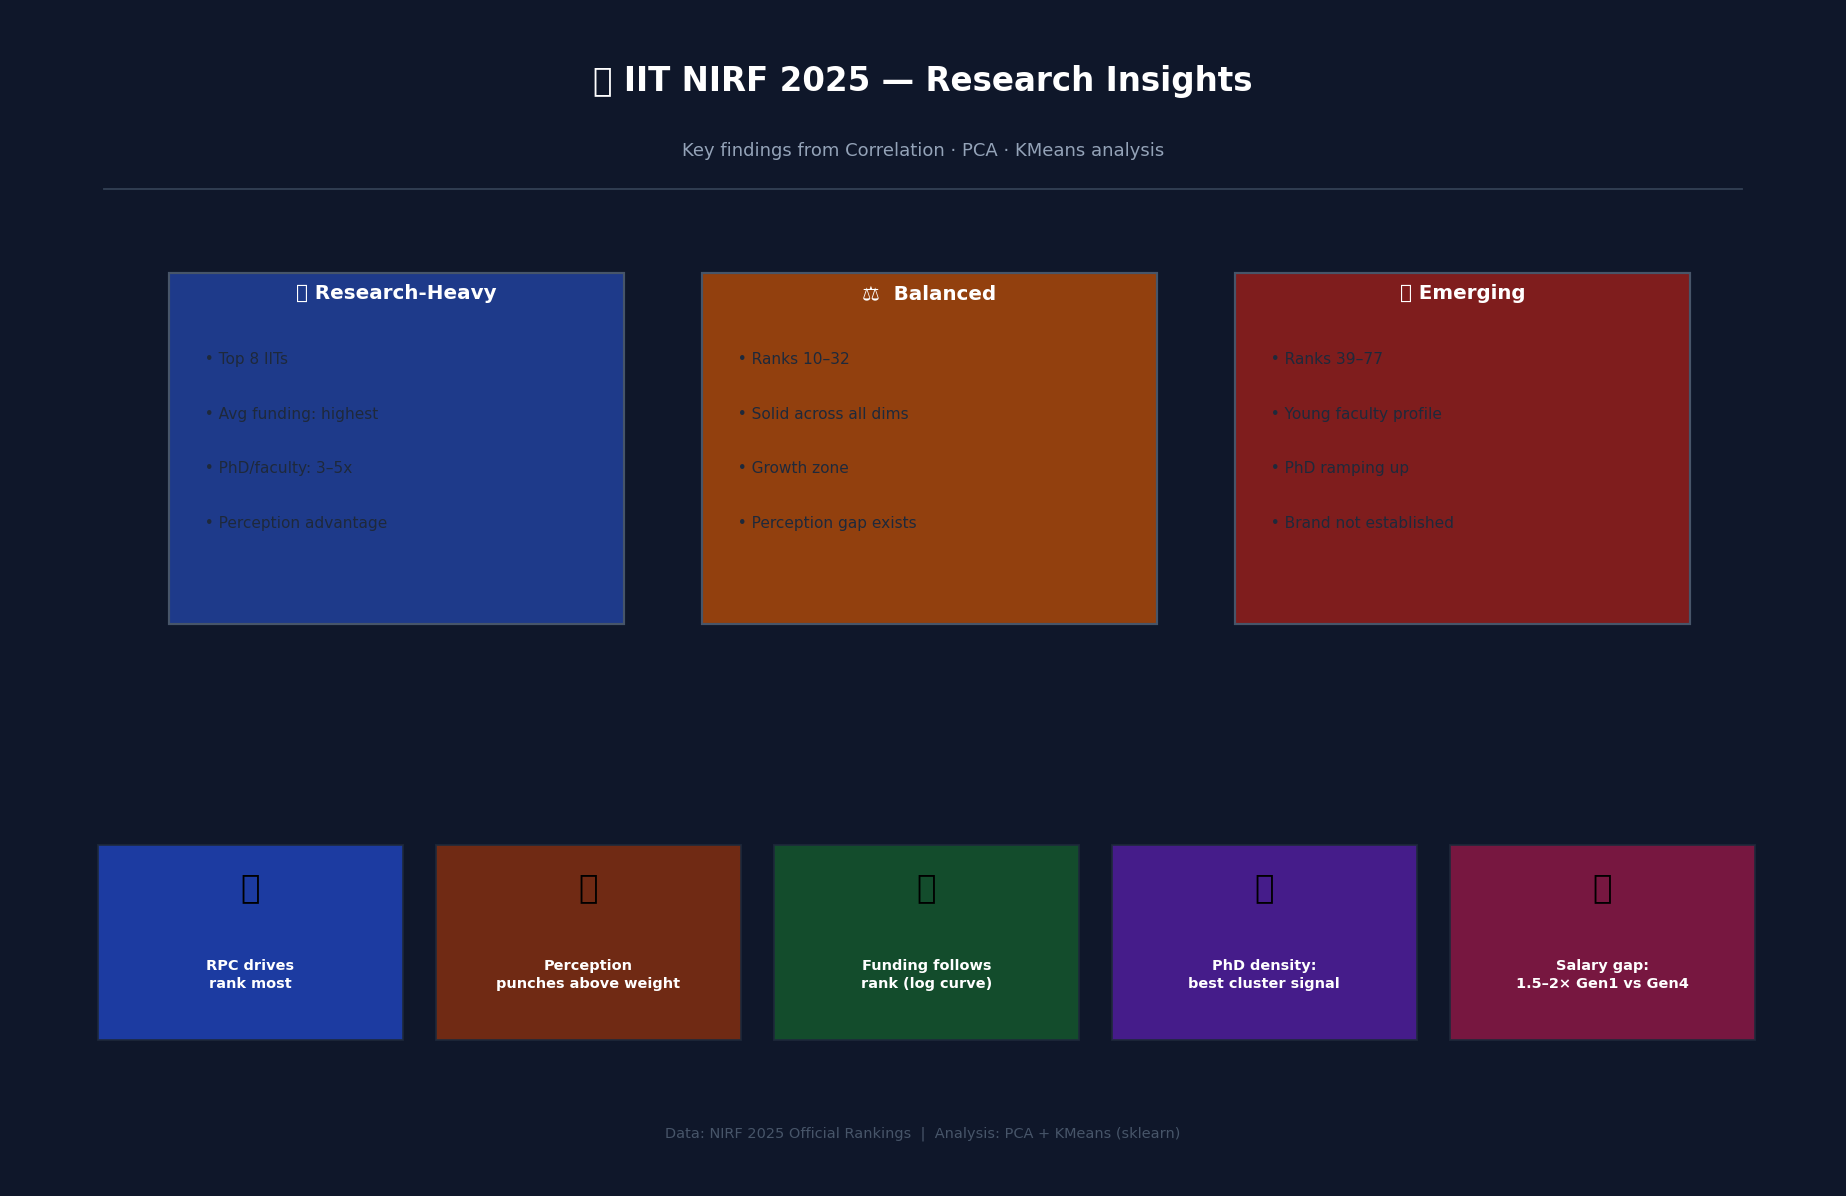

Saved: 28_research_insights_card.png


In [38]:
# ── Visual Key-Findings Card (shareable infographic) ──────────────
fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#0F172A')

ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#0F172A')

# Title
ax.text(7, 8.4, '🎓 IIT NIRF 2025 — Research Insights', ha='center',
        fontsize=18, fontweight='bold', color='white')
ax.text(7, 7.9, 'Key findings from Correlation · PCA · KMeans analysis', ha='center',
        fontsize=10, color='#94A3B8')
ax.axhline(7.65, xmin=0.05, xmax=0.95, color='#334155', lw=1)

# 3 cluster summary boxes
boxes = [
    (1.2,  5.8, '🔬 Research-Heavy',  '#1E3A8A', '#DBEAFE',
     ['Top 8 IITs', 'Avg funding: highest', 'PhD/faculty: 3–5x', 'Perception advantage']),
    (5.3,  5.8, '⚖️  Balanced',        '#92400E', '#FEF3C7',
     ['Ranks 10–32', 'Solid across all dims', 'Growth zone', 'Perception gap exists']),
    (9.4,  5.8, '🚀 Emerging',         '#7F1D1D', '#FEE2E2',
     ['Ranks 39–77', 'Young faculty profile', 'PhD ramping up', 'Brand not established']),
]
for bx, by, bname, bg, fc, lines in boxes:
    rect = plt.Rectangle((bx, by-1.5), 3.5, 2.7, facecolor=bg,
                          edgecolor='#475569', linewidth=1.2, zorder=2)
    ax.add_patch(rect)
    ax.text(bx+1.75, by+1.0, bname, ha='center', fontsize=11,
            fontweight='bold', color='white', zorder=3)
    for j, line in enumerate(lines):
        ax.text(bx+0.2, by+0.5-j*0.42, f'  • {line}', fontsize=8.5,
                color='#1E293B', zorder=3)

# 5 insight tiles at bottom
tiles = [
    ('📐', 'RPC drives\nrank most', '#1E40AF'),
    ('👁', 'Perception\npunches above weight', '#7C2D12'),
    ('💰', 'Funding follows\nrank (log curve)', '#14532D'),
    ('🎓', 'PhD density:\nbest cluster signal', '#4C1D95'),
    ('🏦', 'Salary gap:\n1.5–2× Gen1 vs Gen4', '#831843'),
]
tile_w, tile_h = 2.35, 1.5
start_x = 0.65
for i, (icon, text, color) in enumerate(tiles):
    tx = start_x + i * (tile_w + 0.25)
    ty = 1.1
    rect2 = plt.Rectangle((tx, ty), tile_w, tile_h,
                            facecolor=color, edgecolor='#1E293B',
                            linewidth=1, zorder=2, alpha=0.9)
    ax.add_patch(rect2)
    ax.text(tx + tile_w/2, ty + 1.1, icon, ha='center', fontsize=18, zorder=3)
    ax.text(tx + tile_w/2, ty + 0.4, text, ha='center', fontsize=8,
            color='white', fontweight='bold', zorder=3, linespacing=1.4)

ax.text(7, 0.35, 'Data: NIRF 2025 Official Rankings  |  Analysis: PCA + KMeans (sklearn)',
        ha='center', fontsize=8, color='#475569')

plt.savefig('28_research_insights_card.png', bbox_inches='tight', dpi=150,
            facecolor='#0F172A')
plt.show()
print('Saved: 28_research_insights_card.png')

---
## 9. Export All Results

In [40]:
# ── Cluster assignments CSV ────────────────────────────────────────
export_cols = ['short_name','nirf_rank','nirf_score','generation',
               'cluster_k3_label','cluster_k4_label','PC1','PC2',
               'phd_per_faculty']

# Filter out missing columns dynamically
valid_export_cols = [col for col in export_cols if col in pca_df.columns]

# Export safely, sorting only if nirf_rank exists
if 'nirf_rank' in pca_df.columns:
    pca_df[valid_export_cols].sort_values('nirf_rank').to_csv('iit_cluster_results.csv', index=False)
else:
    pca_df[valid_export_cols].to_csv('iit_cluster_results.csv', index=False)
    print("Note: 'nirf_rank' not found. Exported without sorting.")

print('iit_cluster_results.csv saved ✓')


# ── Cluster summary table ──────────────────────────────────────────
# Define all desired aggregations
desired_aggs = {
    'n_iits':          ('short_name',            'count'),
    'avg_rank':        ('nirf_rank',             'mean'),
    'avg_score':       ('nirf_score',            'mean'),
    'avg_funding_cr':  ('sponsored_funding_cr',  'mean'),
    'avg_salary_l':    ('ug_median_salary_lakh', 'mean'),
    'avg_phd':         ('phd_students_fulltime', 'mean'),
    'avg_patents':     ('patents_granted',       'mean'),
    'avg_phd_density': ('phd_per_faculty',       'mean'),
}

# Filter out aggregations mapping to missing columns
valid_aggs = {
    name: agg_tuple
    for name, agg_tuple in desired_aggs.items()
    if agg_tuple[0] in pca_df.columns
}

# Aggregate and save safely
summary = pca_df.groupby('cluster_k3_label').agg(**valid_aggs).round(2)
summary.to_csv('iit_cluster_summary.csv')
print('iit_cluster_summary.csv saved ✓')


# ── Missing value report CSV ───────────────────────────────────────
# Added a quick try/except just in case 'mv' isn't defined in this run
try:
    mv.to_csv('missing_value_report.csv', index=False)
    print('missing_value_report.csv saved ✓')
except NameError:
    print("Note: DataFrame 'mv' is not defined. Skipped missing_value_report.csv")

print('\n📊 Cluster Summary (k=3):')
display(summary.T)

iit_cluster_results.csv saved ✓
iit_cluster_summary.csv saved ✓
missing_value_report.csv saved ✓

📊 Cluster Summary (k=3):


cluster_k3_label,Balanced,Emerging,Research-Heavy
n_iits,11.00,5.00,6.00
avg_rank,20.00,65.20,3.50
avg_funding_cr,70.68,27.03,402.30
avg_salary_l,17.27,11.66,18.72
avg_phd,878.00,152.40,2745.00
avg_patents,22.45,5.80,93.83


---
## 10. Complete File Index

### Visualizations
| # | File | Section | Description |
|---|------|---------|-------------|
| 01 | `01_score_vs_rank.png` | EDA | NIRF Score vs Rank |
| 02 | `02_subscores_vs_rank.png` | EDA | TLR / RPC / GO / OI / PR panel |
| 03 | `03_salary_vs_rank.png` | EDA | Median UG Salary bar chart |
| 04 | `04_faculty_phd_vs_rank.png` | EDA | Faculty & PhD vs Rank |
| 05 | `05_research_patents_vs_rank.png` | EDA | Funding / Patents / Intensity |
| 06 | `06_radar_top5.png` | EDA | Radar — Top 5 IITs |
| 07 | `07_faculty_age_stacked.png` | Faculty | Age-group stacked bar |
| 08 | `08_faculty_age_gen_compare.png` | Faculty | Gen-1 vs Gen-4 age profile |
| 09 | `09_joining_heatmap.png` | Faculty | Joining-period % heatmap |
| 10 | `10_correlation_heatmap.png` | Correlation | Full 18×18 heatmap |
| 11 | `11_rank_drivers.png` | Correlation | Feature–rank correlation bar |
| 12 | `12_pairplot.png` | Correlation | Pair plot key metrics |
| 13 | `13_pca_scree.png` | PCA | Scree + cumulative variance |
| 14 | `14_pca_2d_generation.png` | PCA | 2D scatter by Generation |
| 15 | `15_pca_biplot.png` | PCA | Biplot with feature arrows |
| 16 | `16_elbow_silhouette.png` | Clustering | Elbow + Silhouette |
| 17 | `17_kmeans_k3.png` | Clustering | k=3 clusters on PCA space |
| 18 | `18_k3_radar_profiles.png` | Clustering | Cluster radar profiles |
| 19 | `19_kmeans_k4.png` | Clustering | k=4 clusters on PCA space |
| 20 | `20_cluster_feature_heatmap.png` | Clustering | Feature heatmap k=3 |
| 21 | `21_missing_value_map.png` | **MV Audit** | IIT × column missing map |
| 22 | `22_dataset_completeness.png` | **MV Audit** | Dataset completeness bars |
| 23 | `23_cluster_boxplots.png` | **Interpretation** | Feature box plots by cluster |
| 24 | `24_perception_bias.png` | **Insights** | Perception weight bias check |
| 25 | `25_funding_vs_rank.png` | **Insights** | Funding diminishing returns |
| 26 | `26_salary_by_generation.png` | **Insights** | Salary gap across generations |
| 27 | `27_phd_density_vs_rank.png` | **Insights** | PhD density vs Rank |
| 28 | `28_research_insights_card.png` | **Insights** | Summary infographic card |

### Data Exports
| File | Description |
|------|-------------|
| `correlation_matrix.csv` | Full 18×18 Pearson correlation matrix |
| `iit_cluster_results.csv` | Per-IIT cluster labels + PC coordinates |
| `iit_cluster_summary.csv` | Mean feature values per k=3 cluster |
| `missing_value_report.csv` | Column-level missing value audit |